# **Notebook : Dataset Reduction – QC and Cohort Definition**
This notebook performs quality control on the raw snRNA-seq dataset, defines the analytical cohort (AD / PD / CTRL), and generates a clean AnnData object (`adata_filtered`) used in the single-cell analysis pipeline.

**Sections**
- Setup and Configuration
- Data Loading (backed mode RAW)
- Exploratory Data Analysis
    - Dataset Overview
    - Dataset Identity Card
    - Comprehensive Data Dictionary
    - Biological Composition & Pathology
    - Demographics
    - Donor Quantification per Disease
    - Age Distribution
    - Pre-computed Embeddings & Visualisation
- Quality Control (QC), Filtering & Cohort Refinement
    - Cell and Gene QC Filtering
        - compute QC metrics
        - filter low-quality nuclei & genes
- Target Cohort Selection and Comorbidity Exclusion
    - AD/PD/CTRL cohort selection
    - ancestry filters
    - creation of `simple_diagnosis`
- Creating the Reduced AnnData Object and Final Summary
    - barplots & tables
- (Optional) Subsampling & Reduced Dataset
- Saving the Filtered Dataset
    - save `adata_filtered` (or `adata_reduced`) to `.h5ad` for the next notebook (`single_cell_pipeline`)


# **Setup block**


### Setup and Configuration

In [2]:
import os
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import igraph
import leidenalg

# PROJECT_ROOT = "/Users/elodiehusson/Desktop/AD & PD" # Elodie
# PROJECT_ROOT = "C:/Users/yarad/Desktop/x/Masters/Master BMC - Sorbonne/M2/Single Cell/Project/Coding Project" # Yara
PROJECT_ROOT = "C:/Z/AIDA_transcriptomics_project/transcriptomics-code"  # Laïla

# --- DÉFINITION DES DOSSIERS ---
DIRS = {
    "DATA":    os.path.join(os.path.dirname(PROJECT_ROOT), "data"),
    "FIGURES": os.path.join(PROJECT_ROOT, "figures"),
    "EDA":     os.path.join(PROJECT_ROOT, "eda_results"),
    "TMP":     os.path.join(PROJECT_ROOT, "tmp_cache")
}

for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

os.chdir(PROJECT_ROOT)

# --- PARAMÈTRES SCANPY ---
sc.settings.figdir = DIRS["FIGURES"]
sc.settings.cachedir = DIRS["TMP"]
sc.settings.datasetdir = DIRS["DATA"]
sc.settings.set_figure_params(dpi=100, frameon=False)

print(f"✅ Environnement chargé. Working directory: {os.getcwd()}")

✅ Environnement chargé. Working directory: C:\Z\AIDA_transcriptomics_project\transcriptomics-code


# **Data Loading**

### Original dataset (RAW) :
Size: 6,28 GB - 26 Disease Types. Downloaded here: https://datasets.cellxgene.cziscience.com/e1fd8b32-0855-4ab2-b1c4-3e9dae6fd3b2.h5ad.

In [3]:
## Emplacement pour elodie 
# adata = sc.read_h5ad("/Users/elodiehusson/Desktop/AD & PD/77k_AD_PD_CTRL.h5ad")

## Path Yara 
# adata = sc.read_h5ad("C:/Users/yarad/Desktop/x/Masters/Master BMC - Sorbonne/M2/Single Cell/Project/Coding Project/AD_PD_CTRL.h5ad")

## Emplacement pour Laïla — backed mode pour éviter MemoryError
#  Le mode backed ne permet PAS : PCA, neighbors, clustering, UMAP, etc.
#  car le dataset n'est pas chargé en RAM (lecture disque uniquement)
dataset_path = os.path.join(DIRS["DATA"], "AD_PD_CTRL.h5ad")
adata = sc.read_h5ad(dataset_path, backed='r')
# adata = sc.read_h5ad(dataset_path)

# print(f"✅ Data loaded.") # Elodie, Yara
print(f"✅ Data loaded (in backed mode)") # Laïla

✅ Data loaded (in backed mode)


# **Exploratory Data Analysis**

### Dataset Overview
Inspect the structure dimensions and inventory the available metadata before processing.

In [4]:
# --- DATASET STRUCTURE & DICTIONARY (FINAL 3-COLUMN LAYOUT) ---
import pandas as pd
import numpy as np
import math
from IPython.display import display, Markdown

# 1. TABLEAU 1 : FICHE D'IDENTITÉ 
overview_data = {
    "Metric": ["Dataset Shape", "Number of Cells", "Number of Genes", "File Mode", "Embeddings (.obsm)"],
    "Value": [f"{adata.shape}", f"{adata.n_obs:,}", f"{adata.n_vars:,}", f"Backed (Read-Only)", list(adata.obsm.keys()) if len(adata.obsm) > 0 else "None"]
}
df_overview = pd.DataFrame(overview_data)

# 2. DICTIONNAIRE DES DONNÉES (Collecte complète)
# On collecte tous les champs de tous les slots (.obs, .var, .obsm, .uns)
inventory = []
for key in sorted(list(adata.obs.columns)):
    inventory.append({"Name": key, "Location": ".obs (Cells)"})
for key in sorted(list(adata.var.columns)):
    inventory.append({"Name": key, "Location": ".var (Genes)"})
for key in sorted(list(adata.obsm.keys())):
    inventory.append({"Name": key, "Location": ".obsm (Coords)"})
for key in sorted(list(adata.uns.keys())):
    inventory.append({"Name": key, "Location": ".uns (Global)"})

df_full = pd.DataFrame(inventory)


# 3. LOGIQUE DE PRÉSENTATION EN 3 COLONNES
N = len(df_full)
N_CHUNK = math.ceil(N / 3) # Taille de chaque colonne

# Division du tableau en 3 parties
df_A = df_full.iloc[0:N_CHUNK].reset_index(drop=True).add_suffix(' (A)')
df_B = df_full.iloc[N_CHUNK:2*N_CHUNK].reset_index(drop=True).add_suffix(' (B)')
df_C = df_full.iloc[2*N_CHUNK:N].reset_index(drop=True).add_suffix(' (C)')

# Fusion horizontale (avec gestion des colonnes vides si N n'est pas un multiple de 3)
df_tri_col = pd.concat([df_A, df_B, df_C], axis=1).fillna("")


# 4. AFFICHAGE FINAL
display(Markdown("### 📊 Dataset Identity Card"))
display(df_overview.style.hide(axis='index'))

display(Markdown(f"### 📚 Comprehensive Data Dictionary ({N} fields in 3 columns)"))
display(df_tri_col.style.hide(axis='index'))

### 📊 Dataset Identity Card

Metric,Value
Dataset Shape,"(693682, 34176)"
Number of Cells,"693,682"
Number of Genes,"34,176"
File Mode,Backed (Read-Only)
Embeddings (.obsm),['X_umap']


### 📚 Comprehensive Data Dictionary (57 fields in 3 columns)

Name (A),Location (A),Name (B),Location (B),Name (C),Location (C)
AD_status,.obs (Cells),disease_ontology_term_id,.obs (Cells),feature_length,.var (Genes)
ASCVD_status,.obs (Cells),donor_id,.obs (Cells),feature_name,.var (Genes)
Bipolar_Disorder,.obs (Cells),genetic_ancestry,.obs (Cells),feature_reference,.var (Genes)
DLBD_status,.obs (Cells),is_primary_data,.obs (Cells),feature_type,.var (Genes)
FTD_status,.obs (Cells),n_counts,.obs (Cells),gene_name,.var (Genes)
Parkinson_disease,.obs (Cells),n_genes,.obs (Cells),n_cells,.var (Genes)
Schizophrenia,.obs (Cells),observation_joinid,.obs (Cells),X_umap,.obsm (Coords)
Source,.obs (Cells),self_reported_ethnicity,.obs (Cells),batch_condition,.uns (Global)
Tardive_dyskinesia,.obs (Cells),self_reported_ethnicity_ontology_term_id,.obs (Cells),citation,.uns (Global)
Tauopathy_status,.obs (Cells),sex,.obs (Cells),class_colors,.uns (Global)


### Biological Composition and Pathological Complexity
Analyze the distribution of major cell classes and the initial prevalence of pathological conditions, including the detection of comorbidities, to assess biological heterogeneity.

📊 Dataset loaded: 693682 cells x 34176 gènes

--- Top 10 Pathological Conditions ---
                                                     Count  Percent (%)
disease                                                                
dementia || Alzheimer disease                       175691        25.33
normal                                              121078        17.45
diabetes mellitus                                    75797        10.93
dementia || Alzheimer disease || diabetes mellitus   50874         7.33
tauopathy                                            47385         6.83
dementia || vascular dementia || Alzheimer disease   31871         4.59
dementia || Alzheimer disease || Parkinson disease   28175         4.06
vascular dementia || diabetes mellitus               26600         3.83
diabetes mellitus || head injury                     17147         2.47
dementia || vascular dementia                        13304         1.92


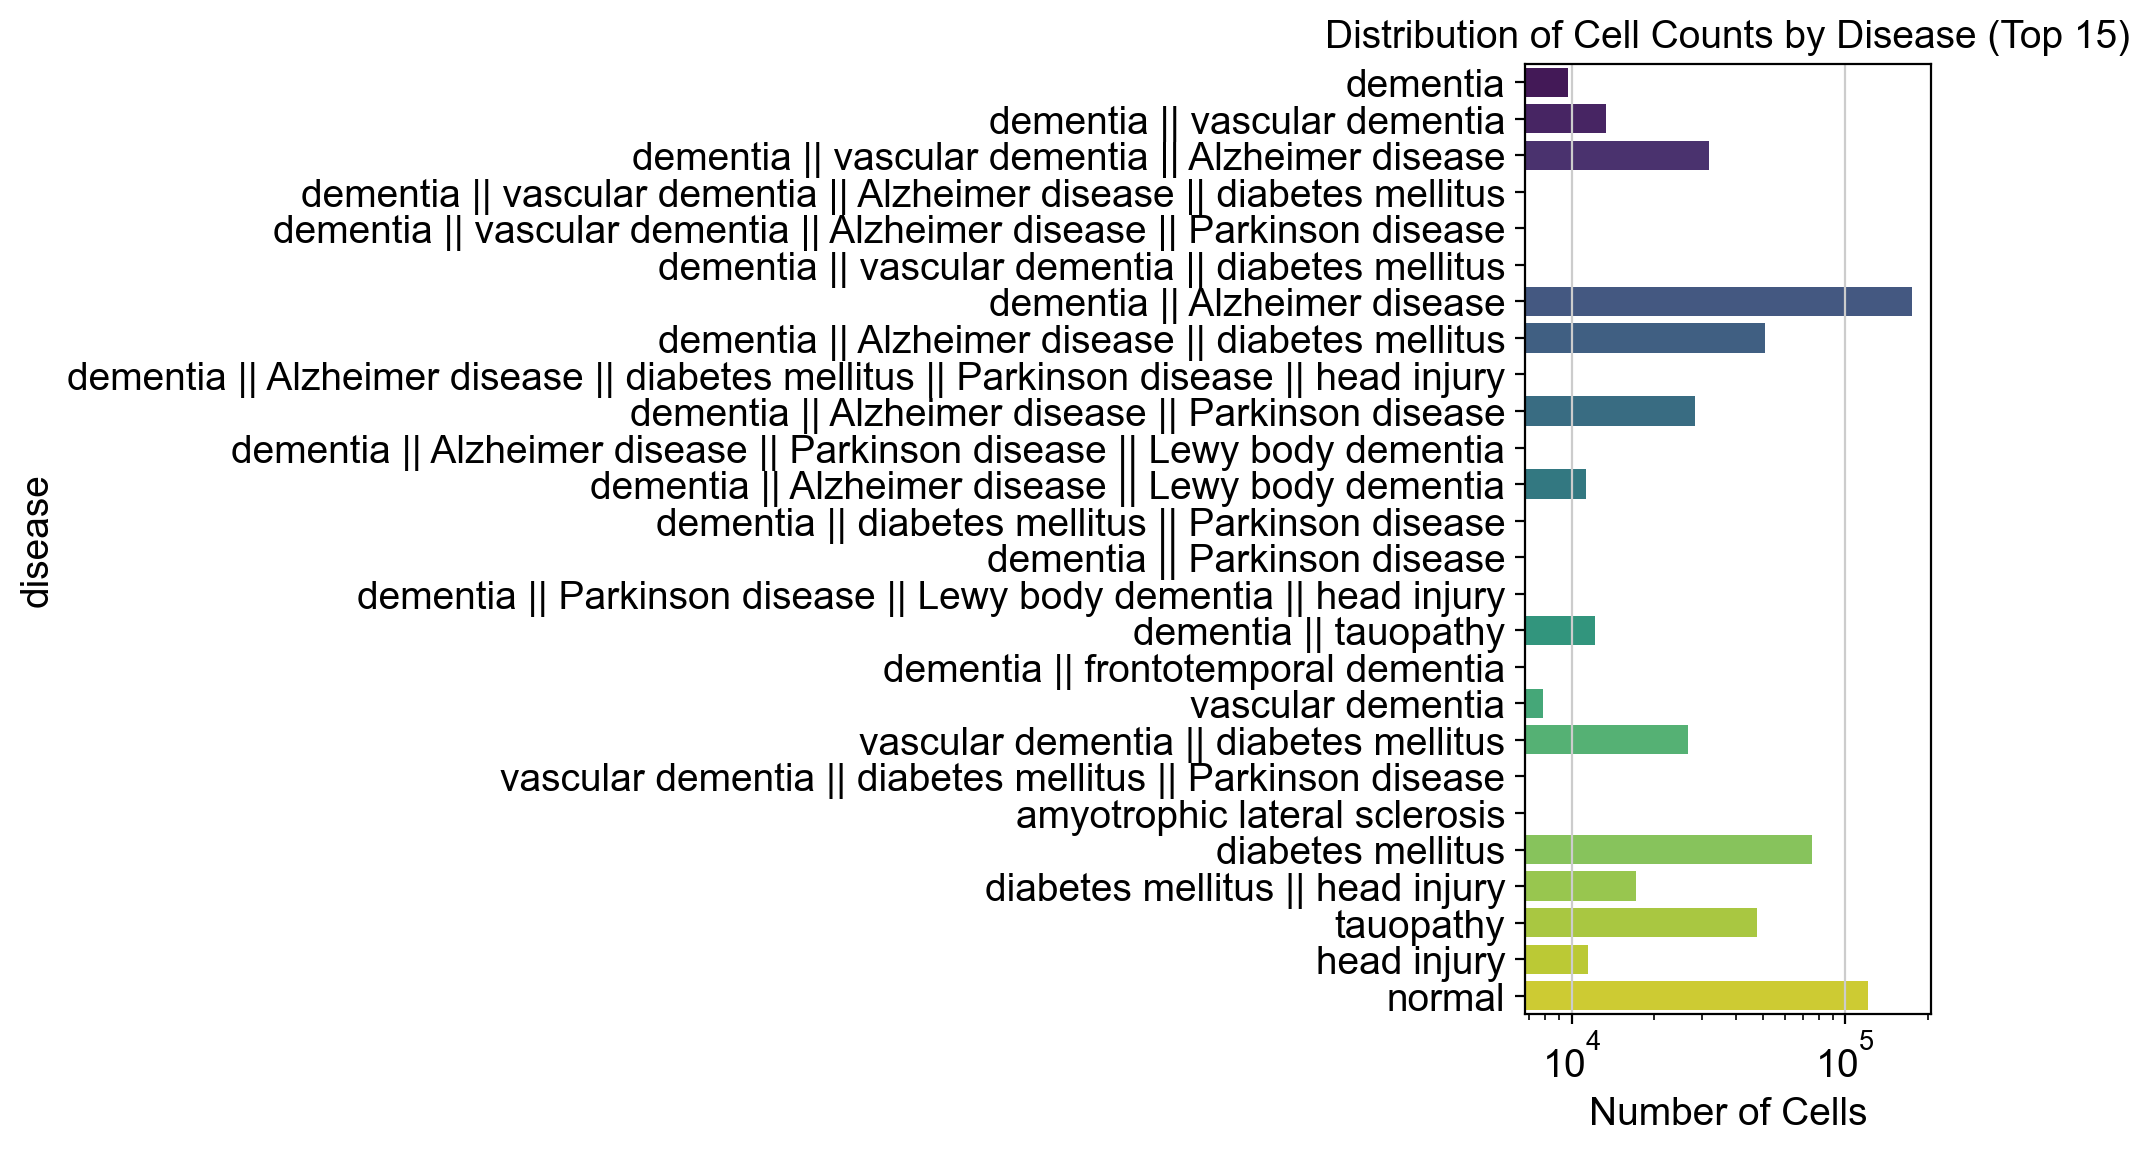


--- Cell Type Distribution ---
         Count  Percent (%)
class                      
Oligo   234151        33.75
EN      182853        26.36
IN      103201        14.88
Astro    86115        12.41
Immune   34201         4.93
OPC      30670         4.42
Mural    13290         1.92
Endo      9201         1.33


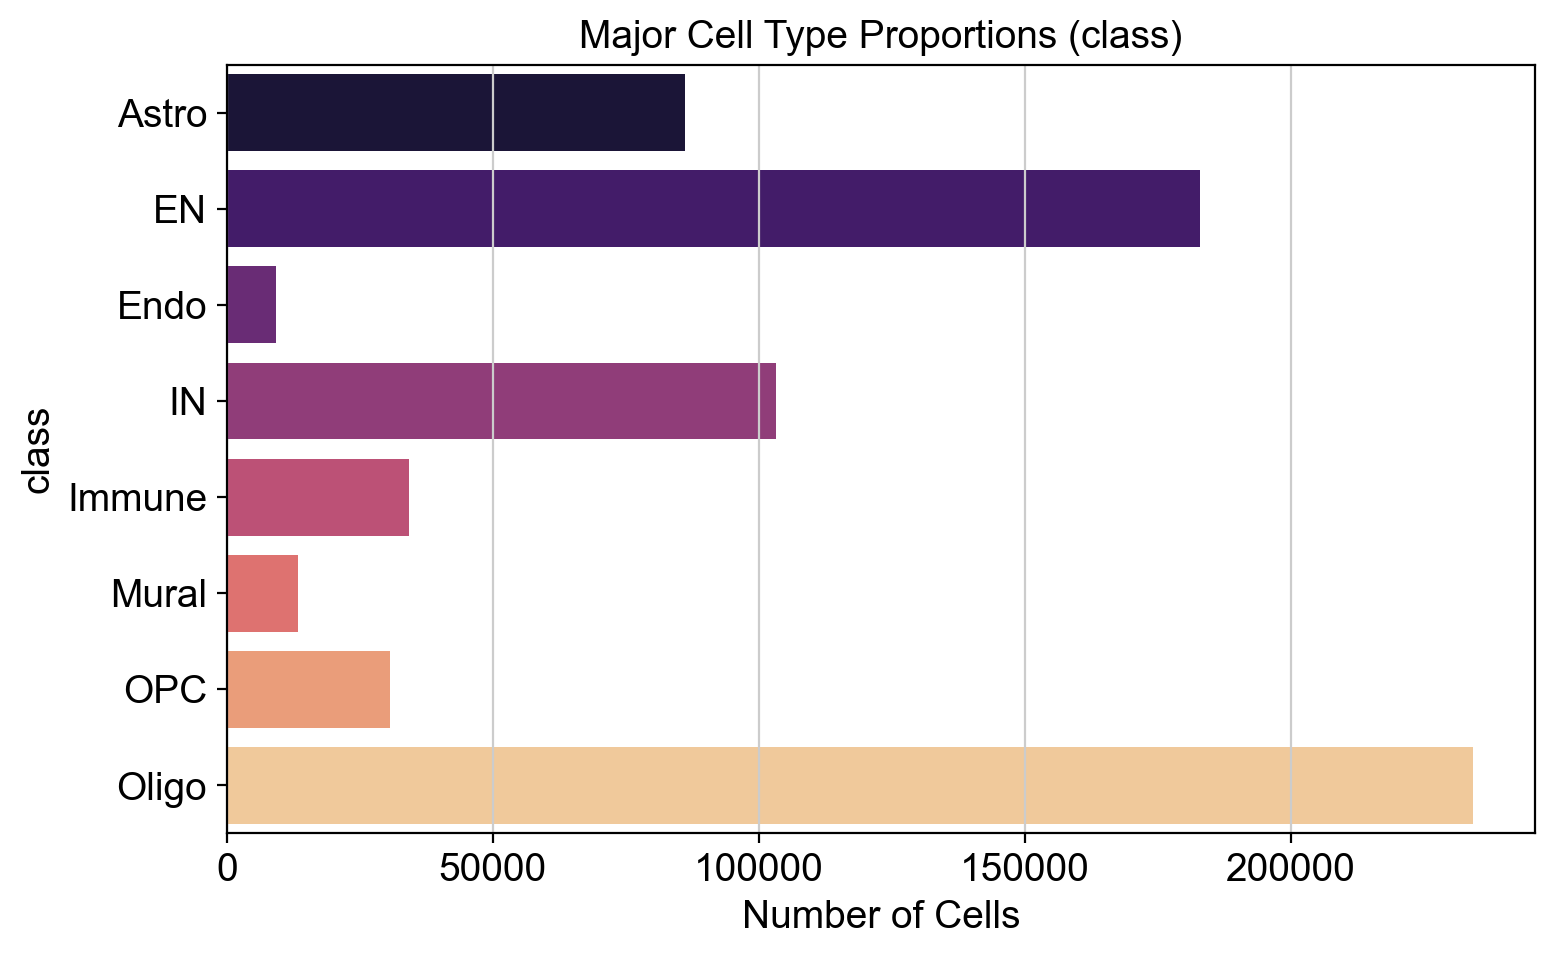


✅ Exploratory Data Analysis completed successfully. Figures saved in: C:/Z/AIDA_transcriptomics_project/transcriptomics-code\eda_results


In [5]:
# --- Note technique : Structure du format AnnData - Annotated Data (.h5ad) ---
# .X    : La Matrice de données (Lignes=Cellules, Colonnes=Gènes, Contient les comptages).
# .obs  : Les Observations (Métadonnées des Cellules). Ex: 'donor_id', 'disease', 'cell_type'.
# .var  : Les Variables (Attributs des Gènes). Ex: 'gene_ids', 'chromosome', 'highly_variable'.
# .obsm : Les Matrices Multidimensionnelles (Coordonnées). Ex: .obsm['X_umap'] contient les coordonnées (x,y) pour le graphique.

# --- EXPLORATORY DATA ANALYSIS (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # On a besoin de pandas explicitement ici
import os
import warnings

# 1. NETTOYAGE
warnings.filterwarnings("ignore") 

# 2. CONFIGURATION DU DOSSIER
if "DIRS" in locals():
    save_dir = DIRS["EDA"]
else:
    save_dir = "./eda_results"
    os.makedirs(save_dir, exist_ok=True)

# 3. VERIFICATION
total_cells = adata.n_obs
print(f"📊 Dataset loaded: {total_cells} cells x {adata.n_vars} gènes")

# --- FONCTION UTILITAIRE POUR AFFICHER LES % ---
def get_counts_and_percentages(series):
    counts = series.value_counts()
    percent = (counts / total_cells) * 100
    # Création d'un beau tableau
    df = pd.DataFrame({'Count': counts, 'Percent (%)': percent.round(2)})
    return df

# --- ANALYSIS 1: DISEASE DISTRIBUTION ---
print("\n--- Top 10 Pathological Conditions ---")
# On utilise notre fonction pour avoir les %
stats_disease = get_counts_and_percentages(adata.obs['disease'])
print(stats_disease.head(10))

# Save table (Maintenant le CSV aura aussi les %)
stats_disease.to_csv(os.path.join(save_dir, "table_diseases_with_percent.csv"))

# Plot
plt.figure(figsize=(10, 6))
# On plotte les 15 premiers
top15 = stats_disease.head(15)
sns.barplot(y=top15.index, x=top15['Count'], palette="viridis")
plt.title("Distribution of Cell Counts by Disease (Top 15)")
plt.xlabel("Number of Cells")
plt.xscale('log') 
plt.tight_layout()

# Save image
plt.savefig(os.path.join(save_dir, "1_disease_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

# --- ANALYSIS 2: CELL TYPES ---
print("\n--- Cell Type Distribution ---")
col_cell = 'class' if 'class' in adata.obs.columns else 'cell_type'
stats_cells = get_counts_and_percentages(adata.obs[col_cell])
print(stats_cells)

# Save table
stats_cells.to_csv(os.path.join(save_dir, "table_cell_types_with_percent.csv"))

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(y=stats_cells.index, x=stats_cells['Count'], palette="magma")
plt.title(f"Major Cell Type Proportions ({col_cell})")
plt.xlabel("Number of Cells")
plt.tight_layout()

# Save image
plt.savefig(os.path.join(save_dir, "2_cell_types_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

# Message de fin propre et complet
print(f"\n✅ Exploratory Data Analysis completed successfully. Figures saved in: {save_dir}")

### Demographics : 
Analysis of the distribution of biological sex, self-reported ethnicity, and sequencing assay technologies across the dataset.

--- Demographic & Technical Summary ---

📊 Variable: sex
         Count  Percent (%)
sex                        
female  464898        67.02
male    228784        32.98


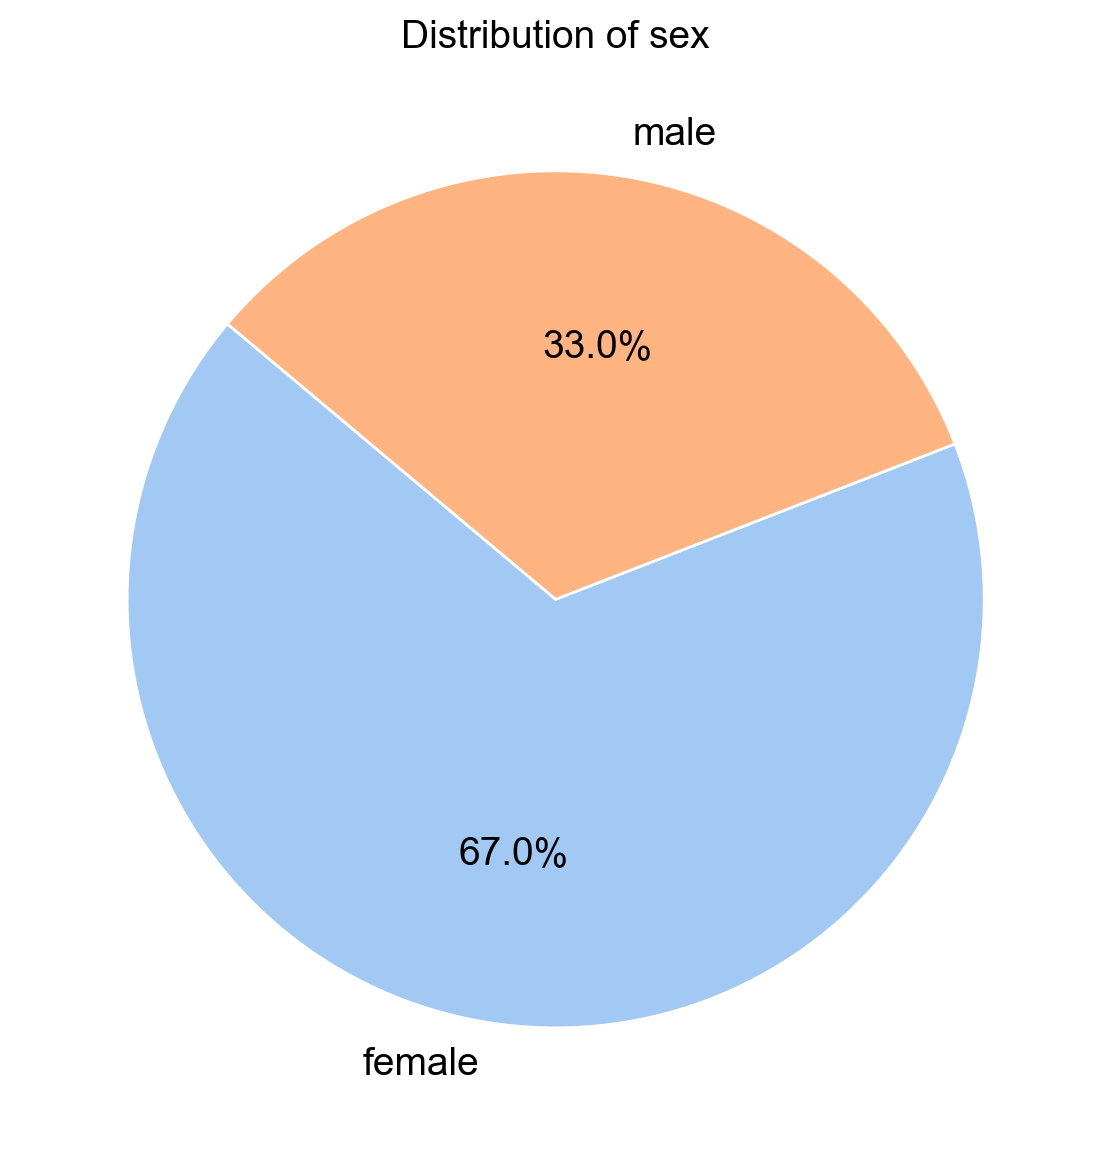


📊 Variable: genetic_ancestry
                   Count  Percent (%)
genetic_ancestry                     
African           408606        58.90
unknown           130601        18.83
European          122187        17.61
East Asian         23964         3.45
Asian               8324         1.20


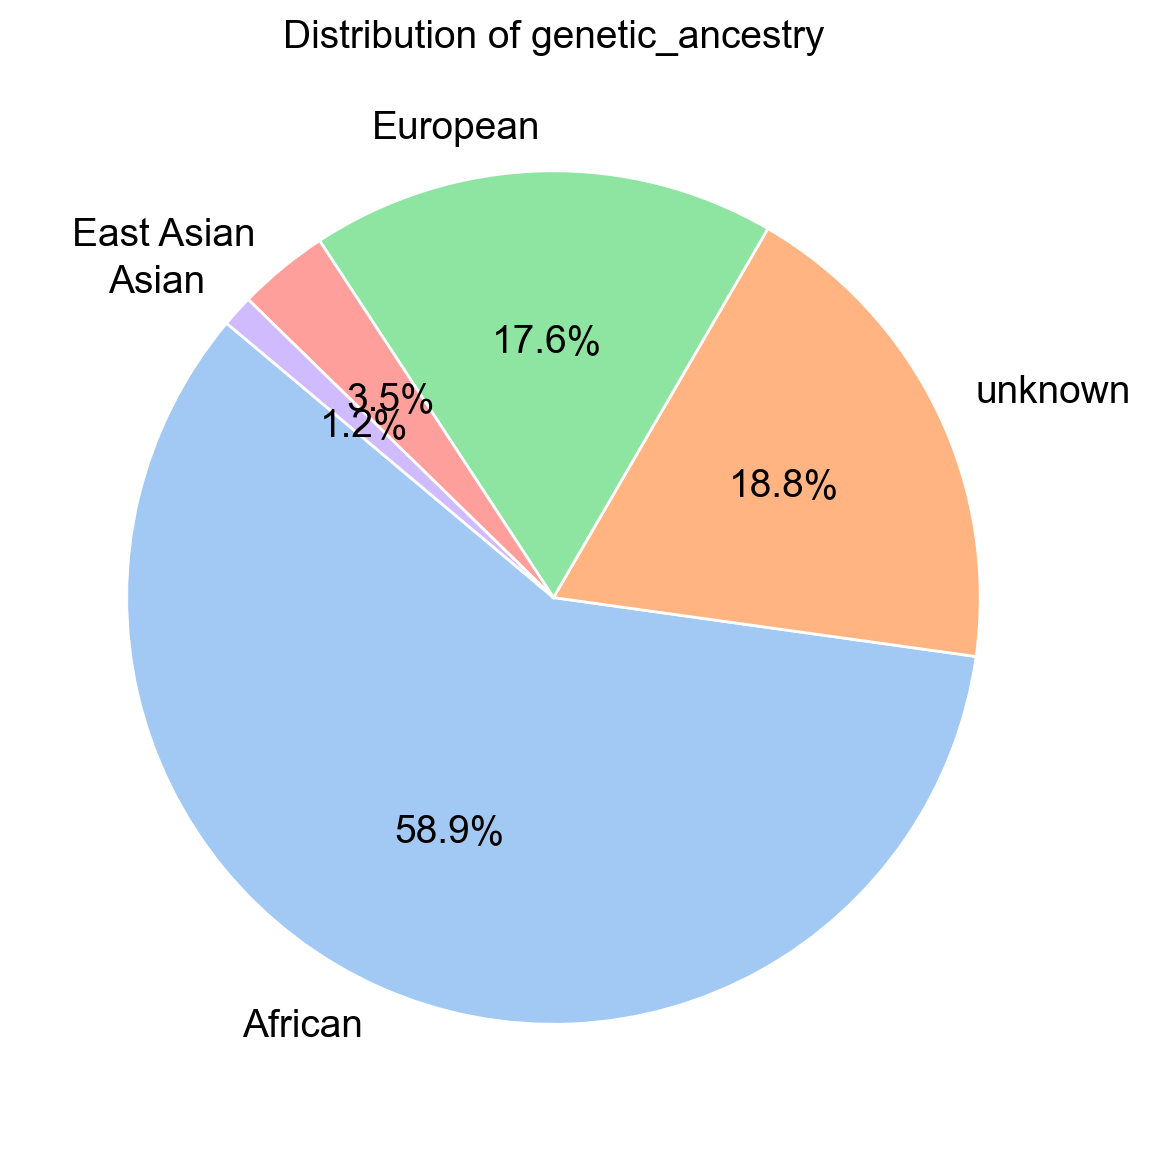


📊 Variable: suspension_type
                  Count  Percent (%)
suspension_type                     
nucleus          693682        100.0


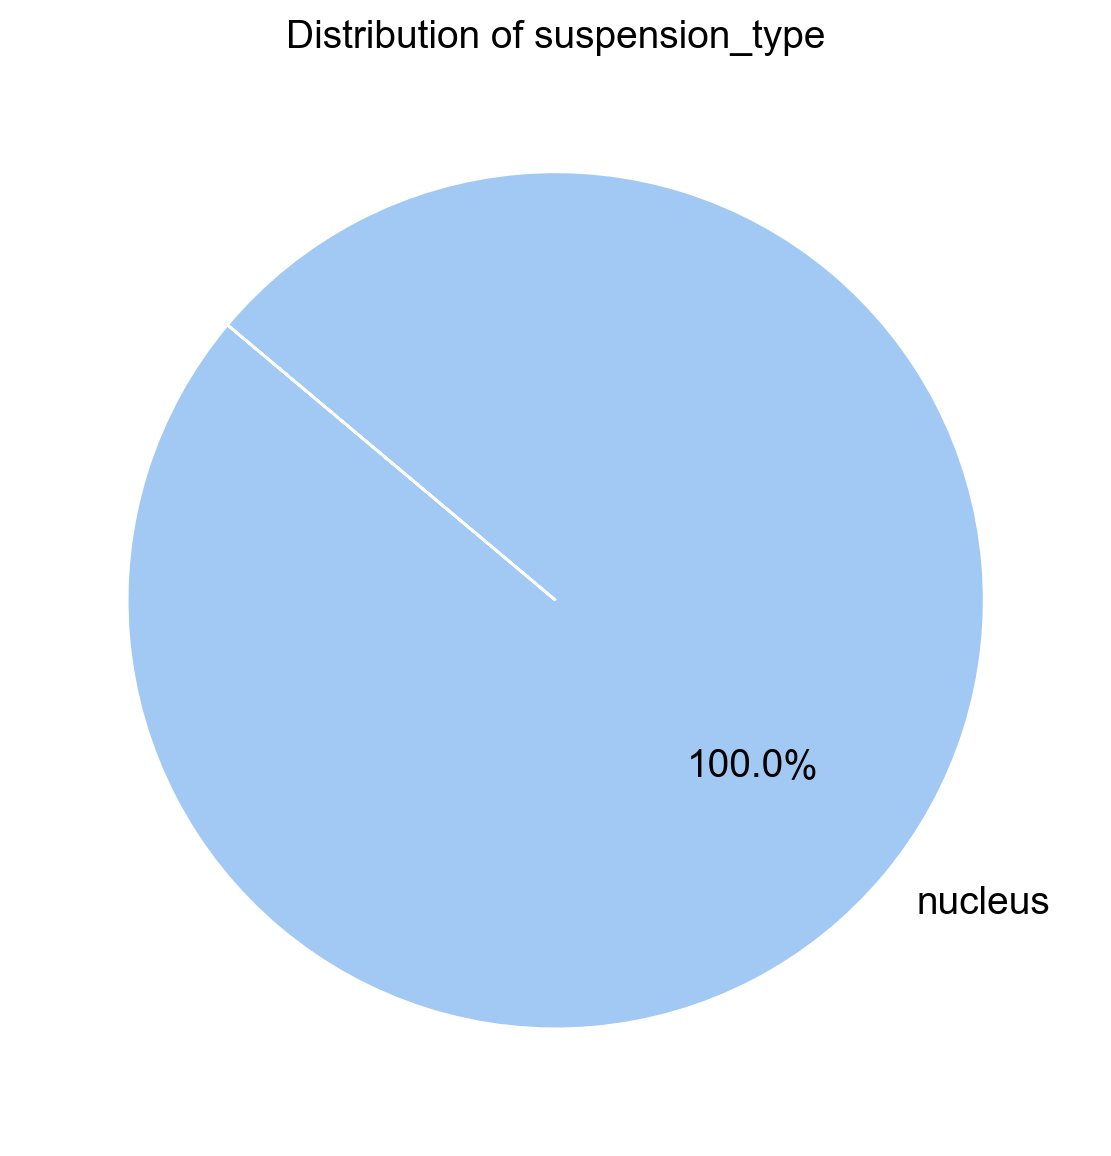


📊 Variable: assay_ontology_term_id
                         Count  Percent (%)
assay_ontology_term_id                     
EFO:0009922             693682        100.0


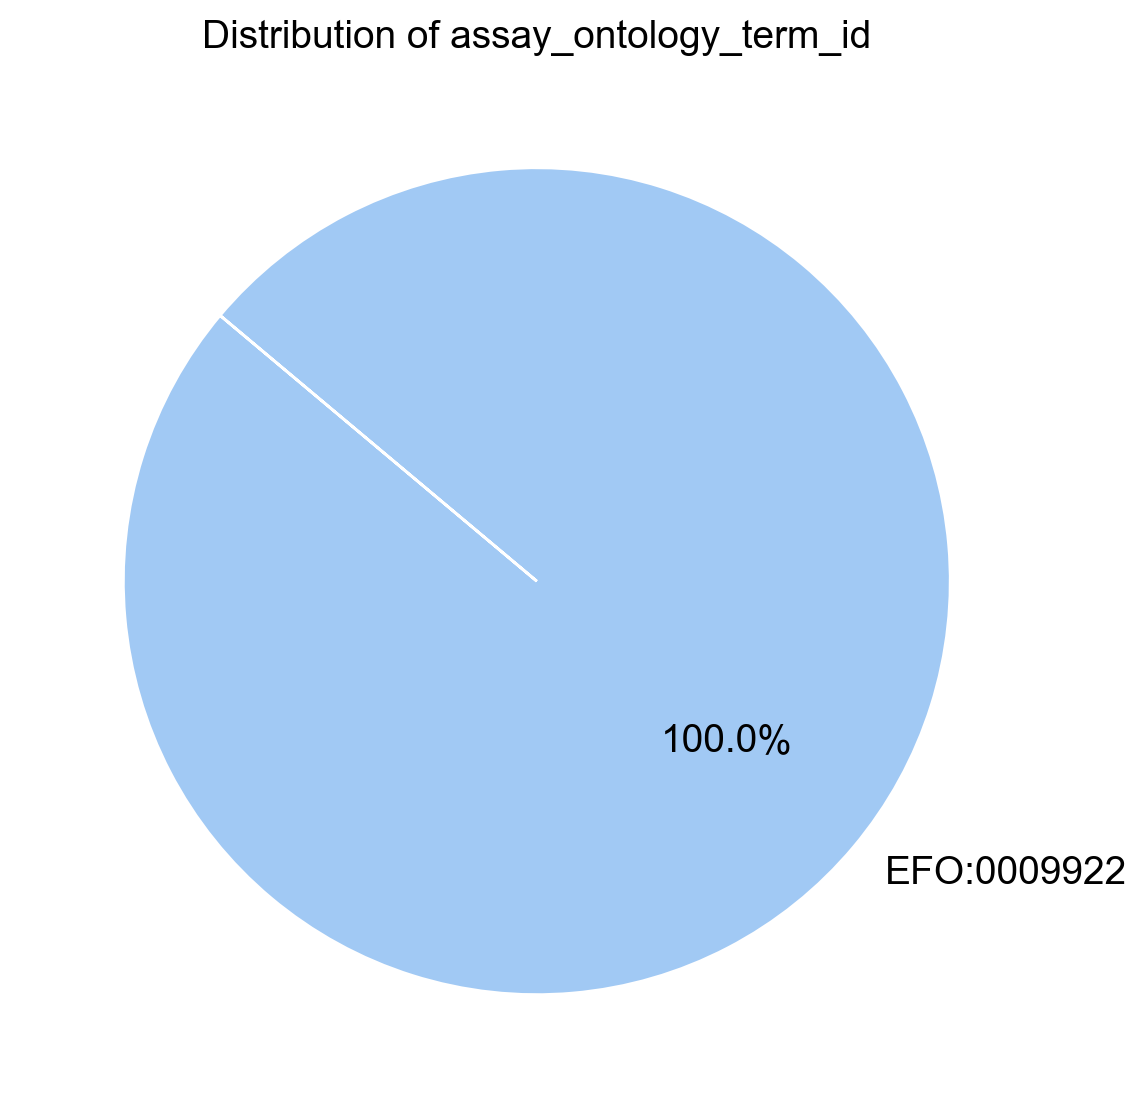

In [9]:
# --- METADATA ANALYSIS: DEMOGRAPHICS & TECH ---
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# C'EST ICI LA MISE À JOUR : On analyse les colonnes pertinentes
variables_to_check = ['sex', 'genetic_ancestry', 'suspension_type', 'assay_ontology_term_id']

print("--- Demographic & Technical Summary ---")

for var in variables_to_check:
    if var in adata.obs.columns:
        print(f"\n📊 Variable: {var}")
        counts = adata.obs[var].value_counts()
        
        # 1. Tableau de données
        df = pd.DataFrame({'Count': counts, 'Percent (%)': ((counts/adata.n_obs)*100).round(2)})
        print(df)
        
        # Sauvegarde CSV
        df.to_csv(os.path.join(DIRS["EDA"], f"table_{var}.csv"))
        
        # 2. Graphique CAMEMBERT (Pie Chart)
        # On ne fait le graphique que s'il y a moins de 20 catégories pour que ce soit lisible
        if len(counts) < 20:
            plt.figure(figsize=(6, 6))
            plt.pie(counts, 
                    labels=counts.index, 
                    autopct='%1.1f%%',
                    startangle=140,
                    colors=sns.color_palette('pastel'),
                    wedgeprops={'edgecolor': 'white'})
            
            plt.title(f"Distribution of {var}")
            plt.tight_layout()
            
            # Sauvegarde Image
            plt.savefig(os.path.join(DIRS["EDA"], f"pie_{var}.png"), dpi=300)
            plt.show()
        else:
            print(f"   -> Too many categories ({len(counts)}) for a pie chart. Skipped.")
        
    else:
        print(f"⚠️ Column '{var}' not found.")

 ### Donor Quantification per Disease
 Single-cell data can be biased if one donor contributes disproportionately to the cell count. Here, we quantify the number of **unique donors** per pathological group to assess the true statistical power of the cohort.


--- Unique Donors per Disease Group (Filtered) ---
                  Unique_Donors
disease                        
Alzheimer's (AD)             41
Control (CTRL)               26
Parkinson's (PD)              3
Graphique sauvegardé sous : C:/Z/AIDA_transcriptomics_project/transcriptomics-code\eda_results\barplot_unique_donors_horizontal.png


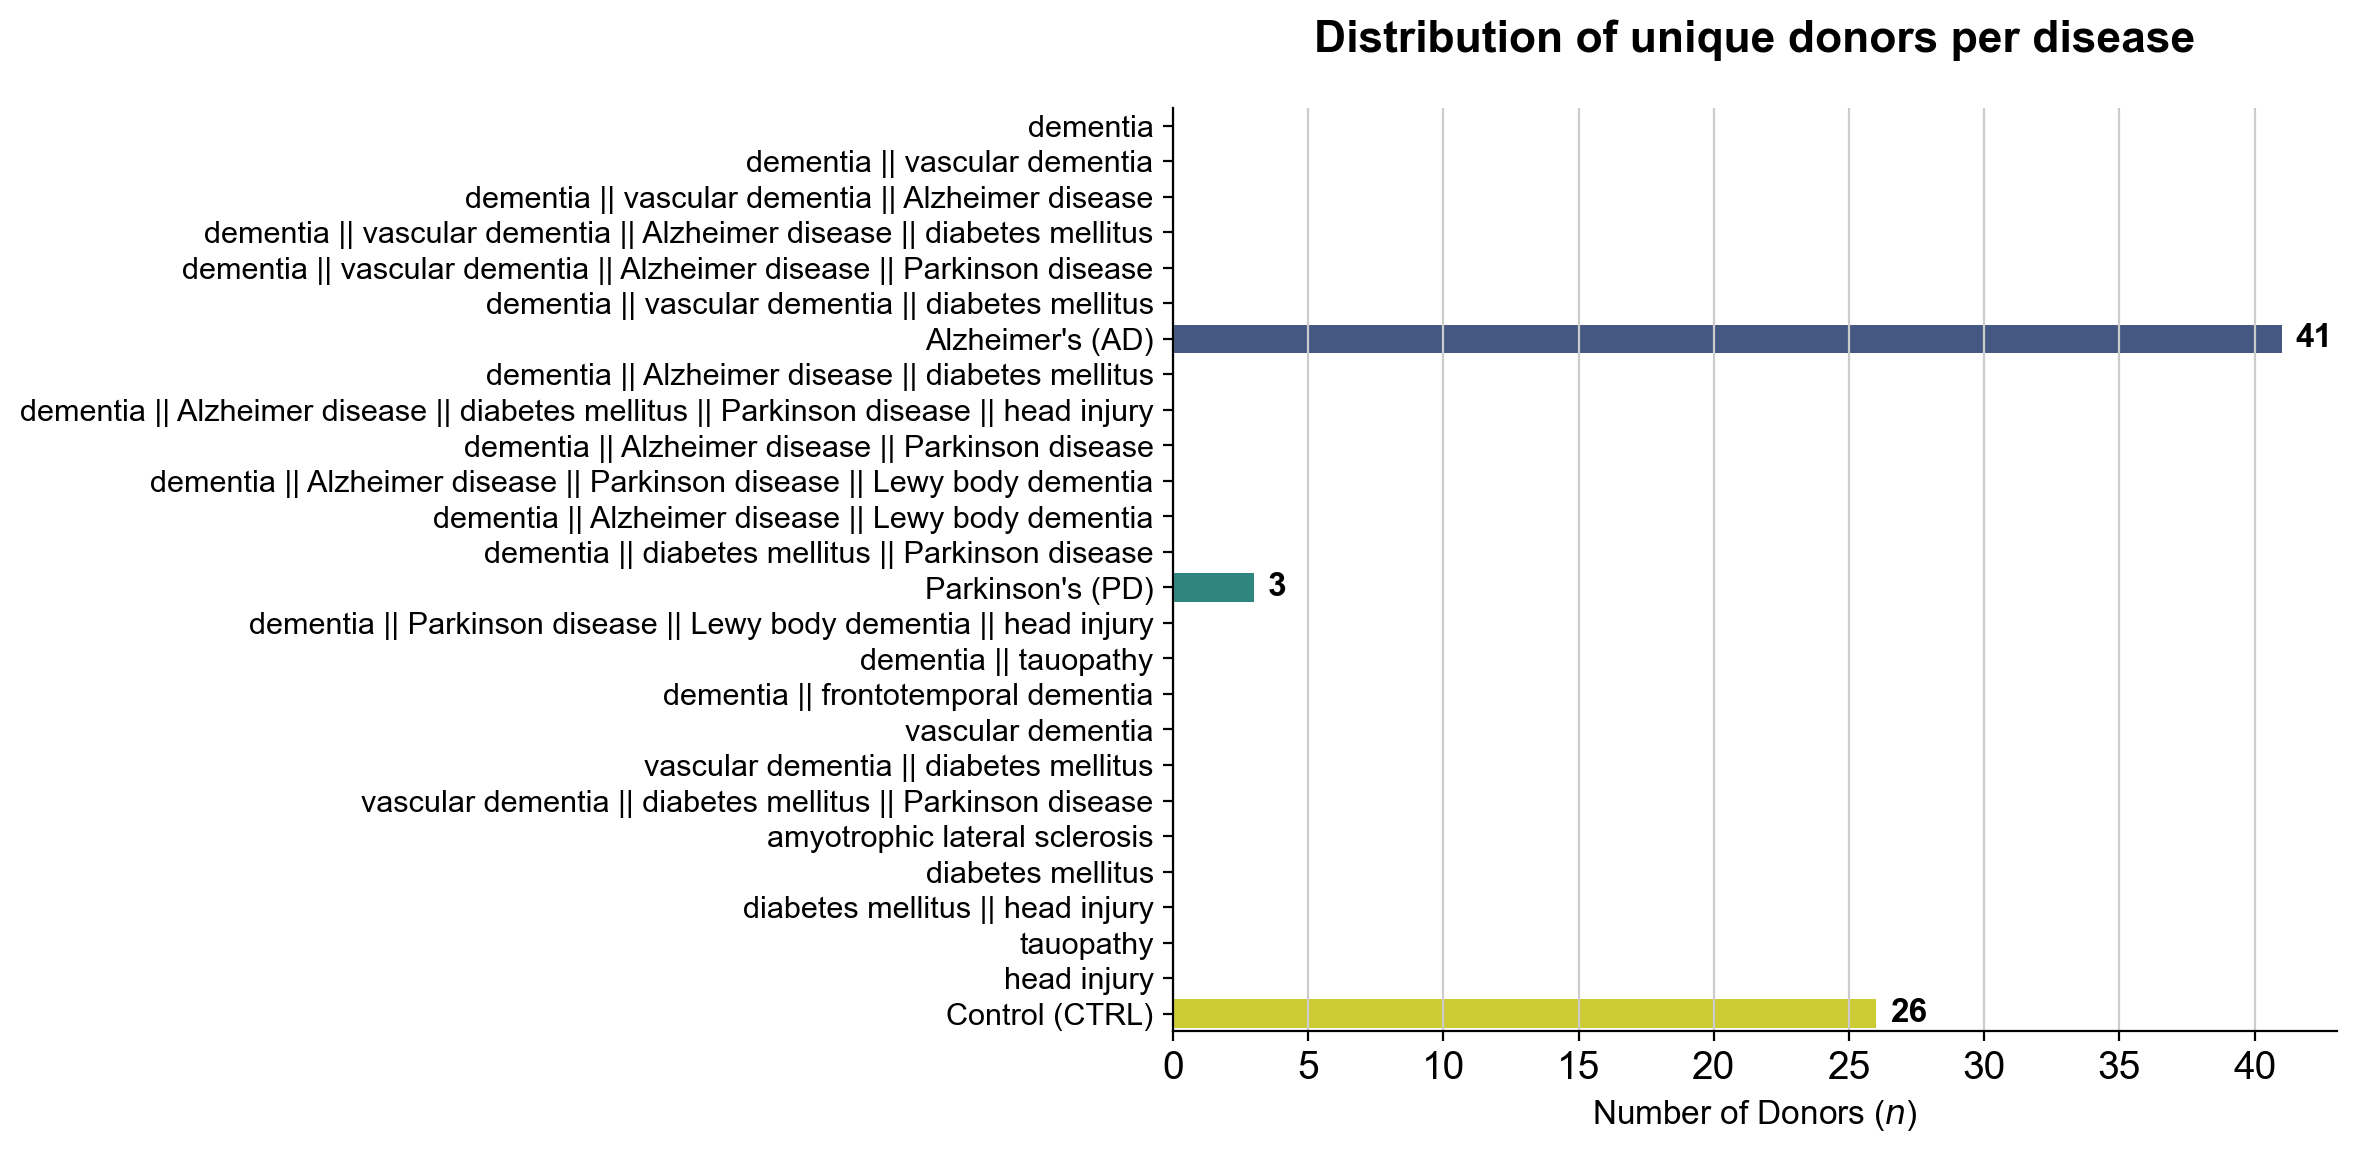

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# --- METADATA ANALYSIS: DONORS (FINAL COHORT) ---
print("\n--- Unique Donors per Disease Group (Filtered) ---")

# 1. CALCULS (Sélection stricte de la cohorte finale)
# On définit les maladies exactes de l'étude
target_diseases = ["dementia || Alzheimer disease", 
                   "dementia || Parkinson disease", 
                   "normal"]

# On filtre temporairement pour le graphique (ne modifie pas 'adata' globalement)
subset_obs = adata.obs[adata.obs['disease'].isin(target_diseases)].copy()

# On renomme pour l'affichage
subset_obs['disease'] = subset_obs['disease'].replace({
    "dementia || Alzheimer disease": "Alzheimer's (AD)",
    "dementia || Parkinson disease": "Parkinson's (PD)",
    "normal": "Control (CTRL)"
})

# Group by disease and count unique donor IDs
donors_stats = subset_obs.groupby("disease", observed=True)["donor_id"].nunique().sort_values(ascending=False)

# Create a summary table
df_donors = pd.DataFrame({
    'Unique_Donors': donors_stats
})

print(df_donors) # Vérification : Doit afficher 8, 6, 3

# 2. VISUALISATION HORIZONTALE (Votre style préservé)
plt.figure(figsize=(12, 6)) 

# Création du Barplot
ax = sns.barplot(
    x=df_donors['Unique_Donors'], 
    y=df_donors.index,            
    palette="viridis"             
)

# TITRES ET LABELS
plt.title("Distribution of unique donors per disease", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Donors ($n$)", fontsize=12)
plt.ylabel("") 

# --- CORRECTION DU "DÉPASSEMENT" ---
plt.yticks(fontsize=11) 
sns.despine()

# AJOUT DES CHIFFRES
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=12, fontweight='bold')

# --- SAUVEGARDE PROPRE ---
plt.tight_layout()

# Save
save_path = os.path.join(DIRS["EDA"], "barplot_unique_donors_horizontal.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
print(f"Graphique sauvegardé sous : {save_path}")

plt.show()
plt.close()

In [12]:
# --- METADATA ANALYSIS: SEX BIAS CHECK ---
print("\n--- Sex Distribution per Disease (Unique Donors) ---")

# On groupe par Maladie ET Sexe, et on compte les donneurs uniques
sex_stats = adata.obs.groupby(["disease", "sex"], observed=True)["donor_id"].nunique()

print(sex_stats)

# Pour avoir un tableau croisé propre :
sex_crosstab = pd.crosstab(
    index=adata.obs.groupby("donor_id")["disease"].first(), # Lignes = Maladie
    columns=adata.obs.groupby("donor_id")["sex"].first()    # Colonnes = Sexe
)

print("\n--- Tableau Croisé (Donneurs) ---")
print(sex_crosstab)

# Sauvegarde pour le rapport
sex_crosstab.to_csv(os.path.join(DIRS["EDA"], "table_sex_distribution.csv"))


--- Sex Distribution per Disease (Unique Donors) ---
disease                                                                                 sex   
dementia                                                                                female     1
                                                                                        male       1
dementia || vascular dementia                                                           female     1
                                                                                        male       1
dementia || vascular dementia || Alzheimer disease                                      female     6
                                                                                        male       1
dementia || vascular dementia || Alzheimer disease || diabetes mellitus                 female     1
dementia || vascular dementia || Alzheimer disease || Parkinson disease                 female     1
dementia || vascular dementia || diabetes m

### Age Distribution (Developmental Stage)
Neurodegenerative diseases are age-related. We analyze the distribution of developmental stages across disease groups to detect potential age mismatches between Control, AD, and PD groups.


--- Age Distribution Matrix (Top 5 Diseases) ---
Graphique compact sauvegardé.


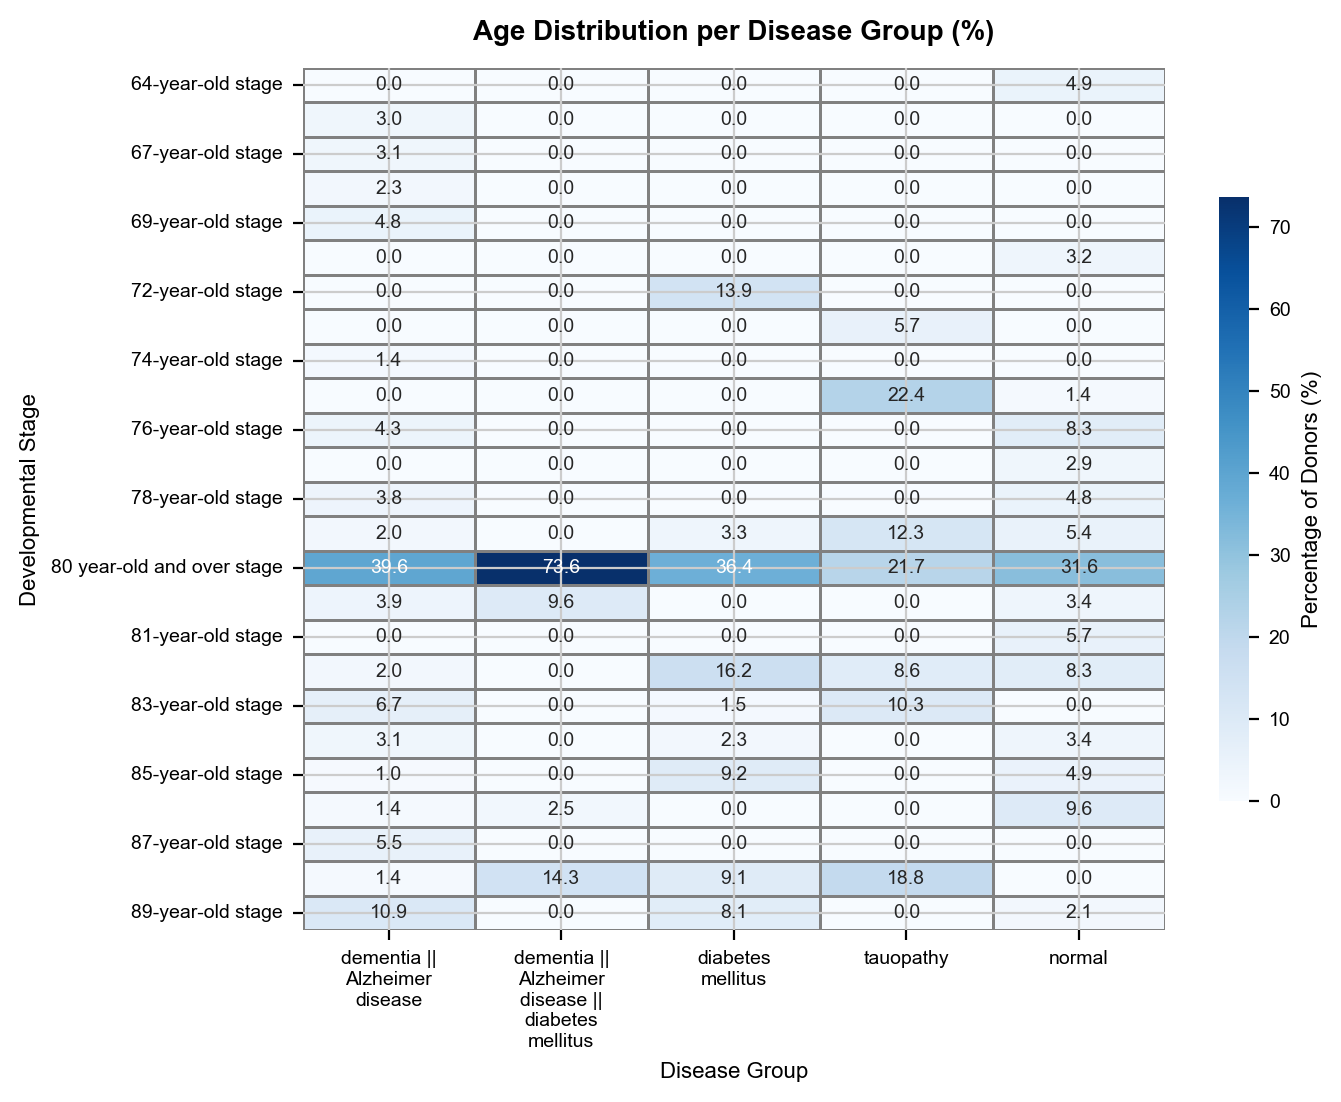

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import textwrap

# --- METADATA ANALYSIS: AGE DISTRIBUTION ---
print("\n--- Age Distribution Matrix (Top 5 Diseases) ---")

# 1. Filter Data (Identique)
top_diseases = adata.obs['disease'].value_counts().head(5).index
subset_age = adata.obs[adata.obs['disease'].isin(top_diseases)]

# 2. Create Pivot Table (Identique)
age_table = pd.crosstab(subset_age['development_stage'], subset_age['disease'])

# 3. Visualization COMPACTE
# MODIFICATION 1 : Réduction drastique de la taille de la figure
plt.figure(figsize=(7, 5.5)) 

# Calcul des pourcentages
age_table_percent = age_table.div(age_table.sum(axis=0), axis=1) * 100

# Fonction Wrapping (Identique)
def wrap_labels(labels, width=12):
    return [textwrap.fill(label, width) for label in labels]

wrapped_labels = wrap_labels(age_table_percent.columns, width=12)

# --- CRÉATION DE LA HEATMAP ---
ax = sns.heatmap(age_table_percent, 
            annot=True, 
            fmt=".1f", 
            cmap="Blues", 
            linewidths=0.5, 
            linecolor='gray',
            xticklabels=wrapped_labels,
            annot_kws={"size": 7}, # Police intérieure légèrement réduite pour aller avec la petite taille
            # MODIFICATION 2 : La barre de légende (colorbar) est réduite (shrink) pour gagner de la place
            cbar_kws={'label': '', 'shrink': 0.7} 
            )

# --- AJUSTEMENT DES TEXTES ---
plt.title("Age Distribution per Disease Group (%)", fontsize=10, fontweight='bold', pad=10)
plt.xlabel("Disease Group", fontsize=8)
plt.ylabel("Developmental Stage", fontsize=8)

# --- AJUSTEMENT DES TICKS ---
plt.xticks(
    rotation=0, 
    ha='center', 
    fontsize=7  # Adapté à la nouvelle taille
)
plt.yticks(
    fontsize=7 
)

# --- AJUSTEMENT DE LA COLORBAR ---
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7) 
cbar.set_label('Percentage of Donors (%)', fontsize=8)

# MODIFICATION 3 : Marges ultra-fines
plt.tight_layout(pad=0.5)

# Save
plt.savefig(os.path.join(DIRS["EDA"], "heatmap_age_disease_compact.png"), dpi=300)
print("Graphique compact sauvegardé.")
plt.show()

### Pre-computed Embeddings & Visualisation 
The downloaded atlas comes with pre-computed coordinates (UMAP). We visualize the global structure of the dataset to verify cell type separation and batch integration before processing.


🎨 Generating individual UMAP plots...
   -> Plotting class...


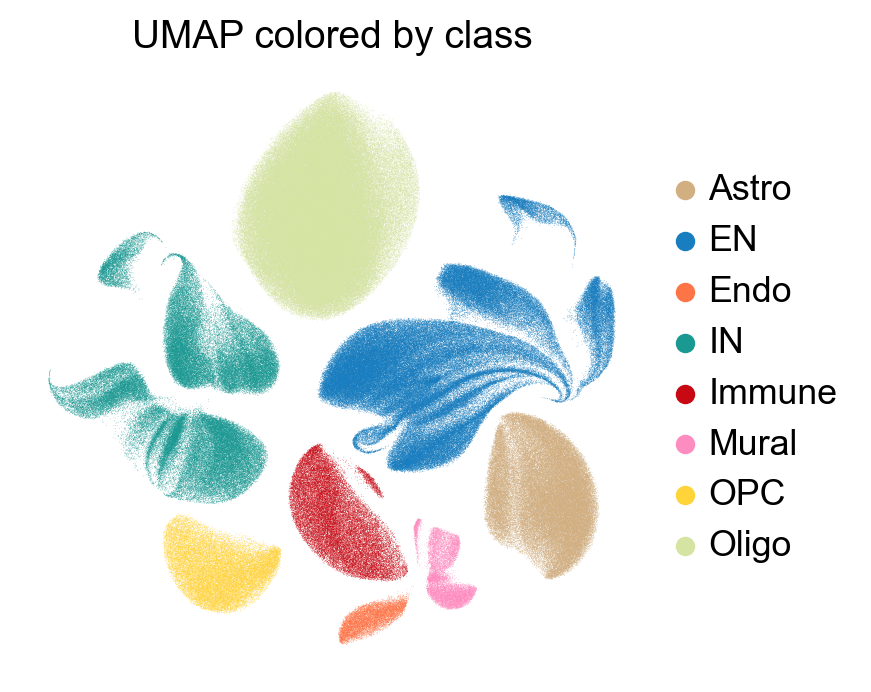

   -> Plotting cell_type...


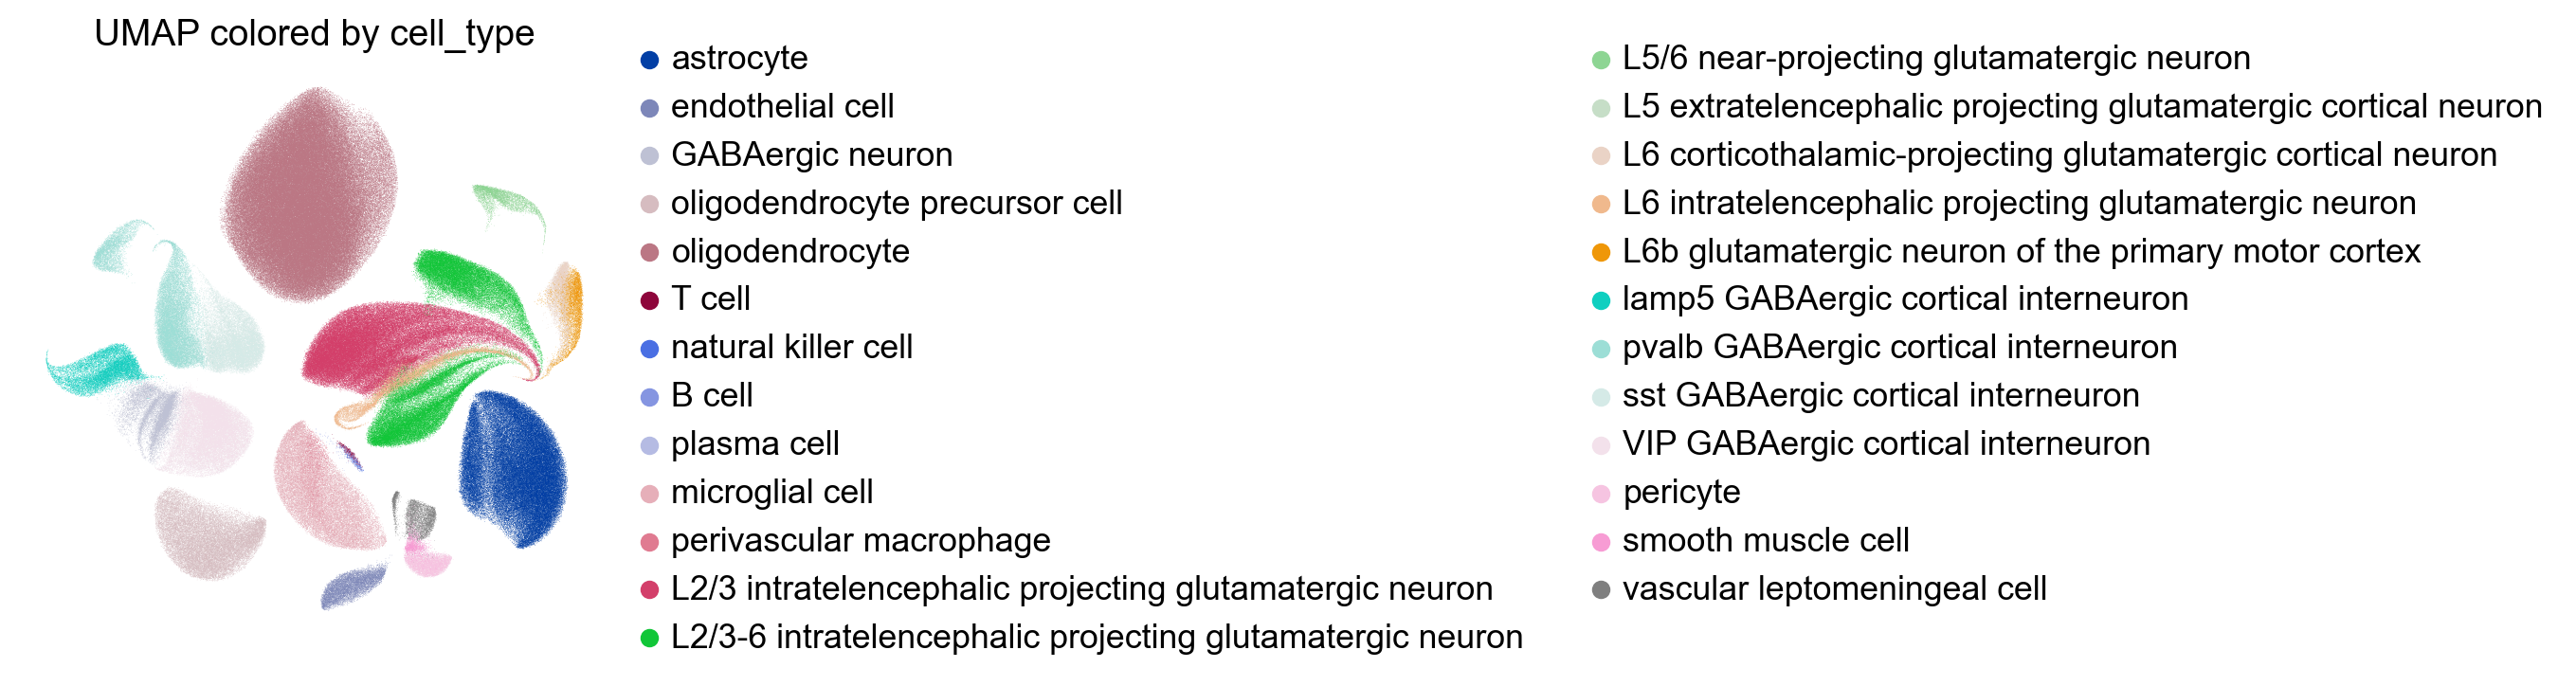

   -> Plotting subclass...


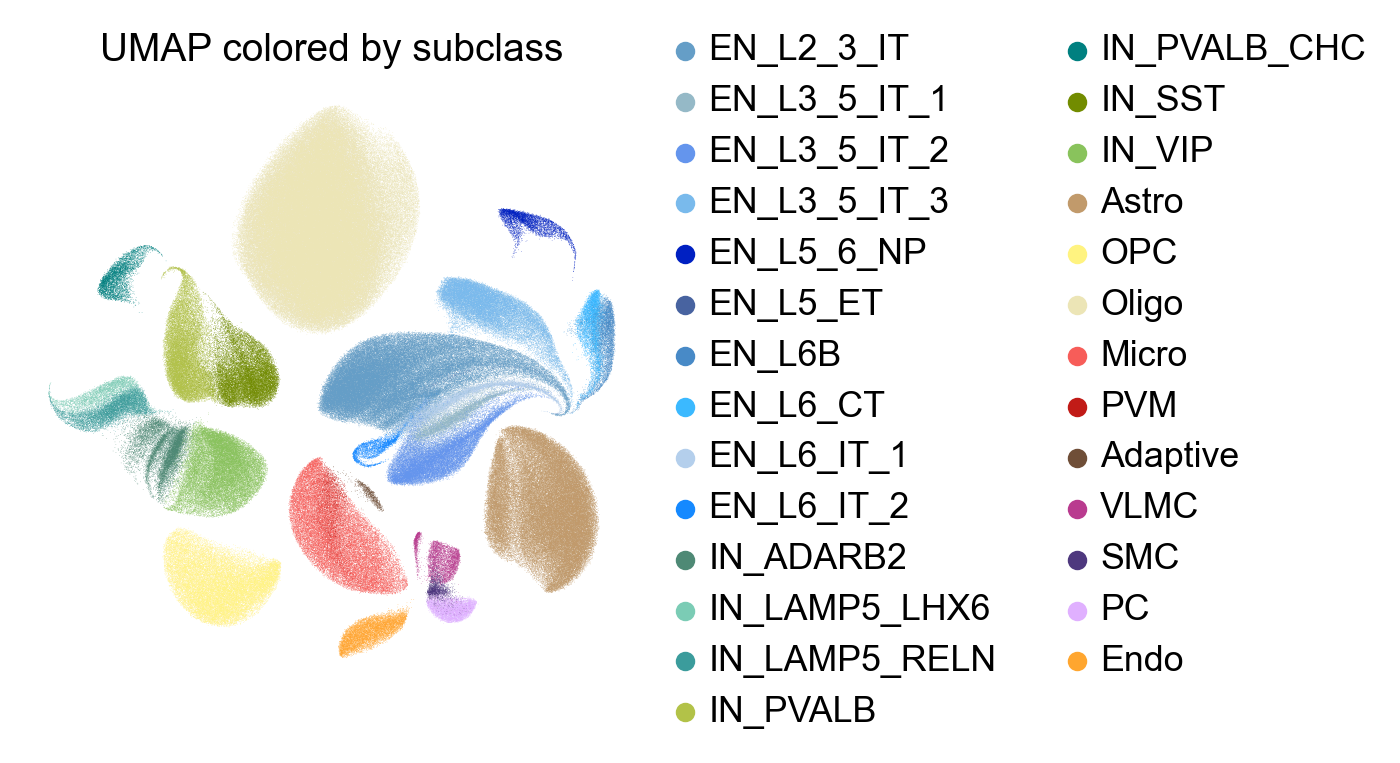

   -> Plotting disease...


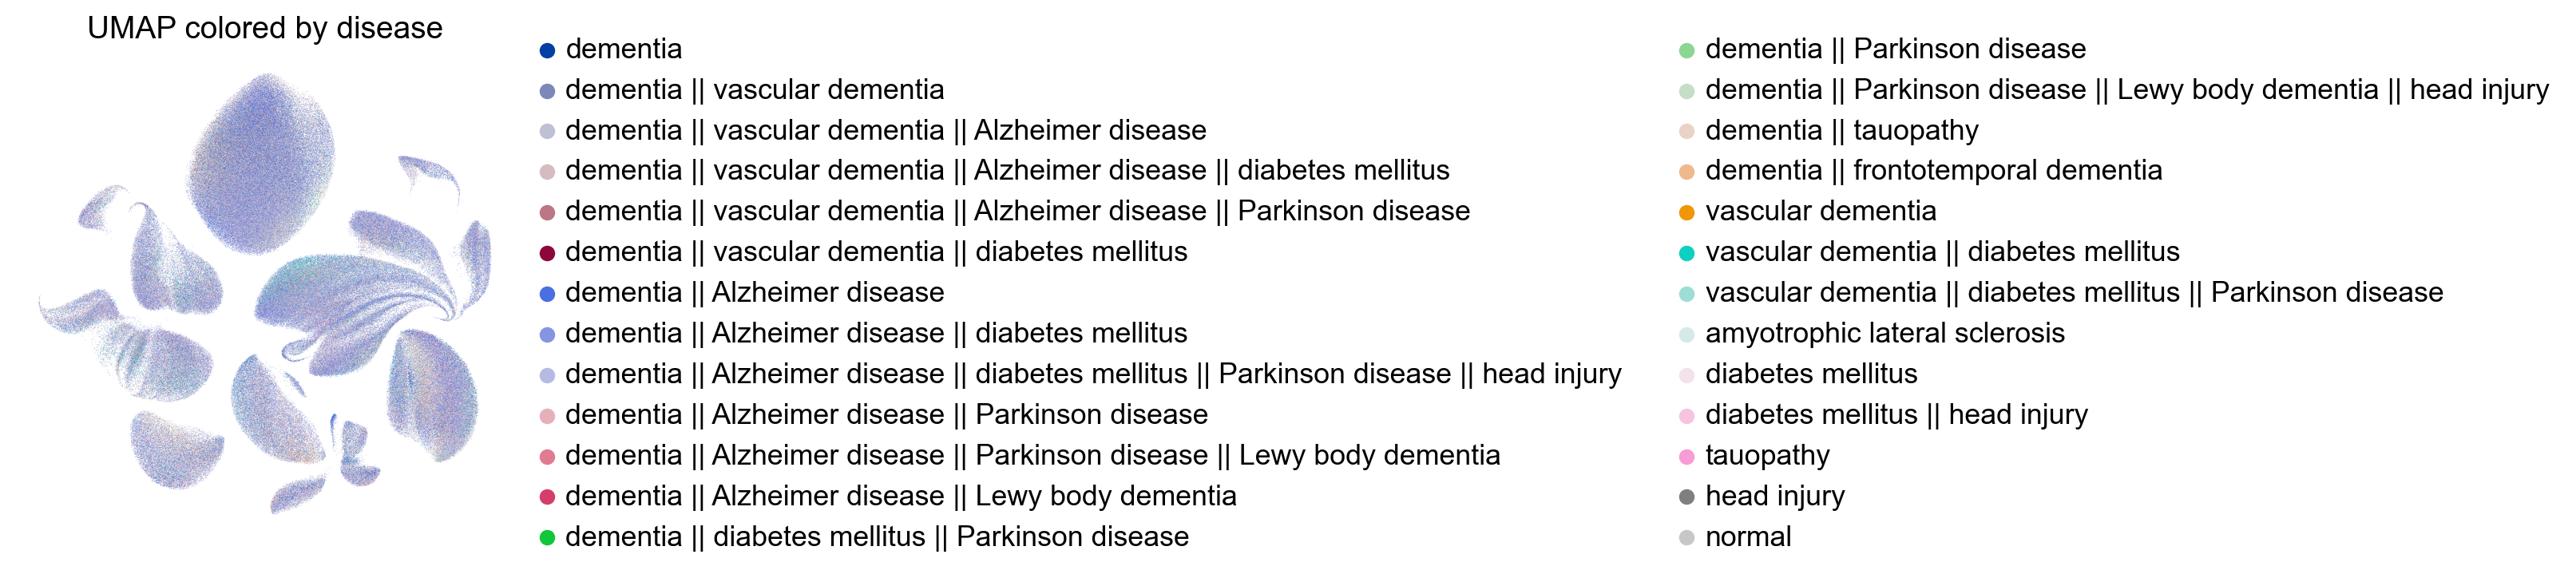

   -> Plotting sex...


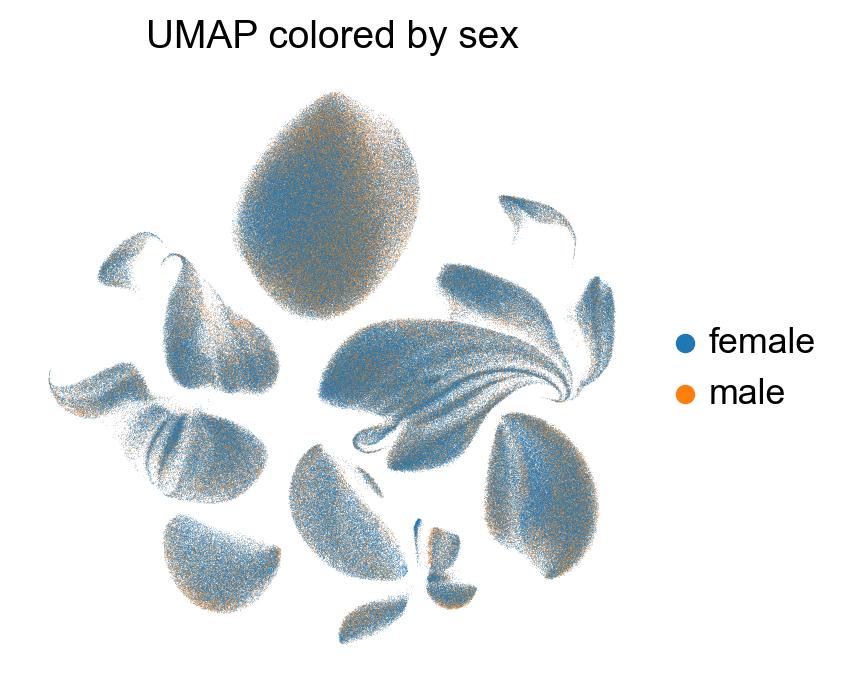

✅ All UMAPs saved in: C:/Z/AIDA_transcriptomics_project/transcriptomics-code\figures


In [14]:
# --- METADATA: EMBEDDINGS & VISUALIZATION ---
# Vérification : Est-ce qu'il y a bien une UMAP pré-calculée ?
if "X_umap" in adata.obsm.keys():
    print("\n🎨 Generating individual UMAP plots...")
    
    # Liste des couleurs à afficher
    color_list = []
    # On ajoute les colonnes intéressantes si elles existent
    for col in ['class', 'cell_type', 'subclass', 'disease', 'sex']:
        if col in adata.obs.columns:
            color_list.append(col)
    
    # BOUCLE : Un graphique par ligne
    for col in color_list:
        print(f"   -> Plotting {col}...")
        
        # On crée une figure dédiée
        sc.pl.umap(adata, 
                   color=col, 
                   frameon=False,        # Pas de cadre
                   title=f"UMAP colored by {col}", # Titre clair
                   save=f"_precomputed_{col}.png") # Fichier unique
               
    print(f"✅ All UMAPs saved in: {DIRS['FIGURES']}")
else:
    print("⚠️ No pre-computed UMAP ('X_umap') found in this dataset.")

# **Quality Control (QC) & Cohort Refinement**

### Cell and Gene Quality Control (QC) Filtering
Calculate and apply standard QC metrics (Mitochondrial genes, n_genes) to the raw dataset to remove technical artifacts and low-quality cells prior to clinical filtering.

**0-Technical Pre-Filtering (RAM Optimization):**
Reduce the total cell count by approximately 58% to allow subsequent memory-intensive operations (QC metrics calculation) to run in-memory, circumventing the critical RAM bottleneck.

In [15]:
import scanpy as sc
import numpy as np
import gc

try:
    del adata
    del adata_raw
except:
    pass

adata_raw = sc.read_h5ad(dataset_path, backed='r')
indices = np.where(adata_raw.obs['genetic_ancestry'] != "African")[0]

adata_prefiltered = adata_raw[indices, :] 
adata = adata_prefiltered.to_memory()  

try:
    del adata_raw
    del adata_prefiltered
except:
    pass
gc.collect()

print("Indices kept:", len(indices))
print("Prefiltered cells (Technical considerations):", adata.n_obs)

print(f"✅ Technical pre-filtering successful: dataset reduced to {adata.n_obs:,} cells, enabling in-memory QC computation.")


Indices kept: 285076
Prefiltered cells (Technical considerations): 285076
✅ Technical pre-filtering successful: dataset reduced to 285,076 cells, enabling in-memory QC computation.


**1-Calculation of Initial QC Metrics:**
Ccalculate quality metrics (pct_counts_mt, n_genes) on the raw adata object to prepare for the filtering phase.

In [16]:
# --- 4.1.1 CALCUL DES MÉTRIQUES QC (SUR LA DONNÉE BRUTE) ---
print("⚙️ Calculating QC metrics on the full raw dataset...")

# 1. Identification des gènes mitochondriaux
# Les gènes mitochondriaux (MT) sont souvent des indicateurs de stress ou de mort cellulaire.
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 2. Calcul des métriques et ajout dans adata.obs
# Attention : Si cette ligne produit une erreur (AxisError), c'est la contrainte de RAM qui gagne
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(f"✅ QC Metrics added to adata.obs: n_genes, n_counts, pct_counts_mt")
print(adata.obs[['n_genes_by_counts', 'n_counts', 'pct_counts_mt']].describe())

⚙️ Calculating QC metrics on the full raw dataset...
✅ QC Metrics added to adata.obs: n_genes, n_counts, pct_counts_mt
       n_genes_by_counts       n_counts  pct_counts_mt
count      285076.000000  285076.000000       285076.0
mean         3793.766364   12617.154297            0.0
std          1994.616847   13390.646484            0.0
min           988.000000    1247.000000            0.0
25%          2346.000000    4715.000000            0.0
50%          3195.000000    7739.000000            0.0
75%          4714.000000   14769.250000            0.0
max         13607.000000  163298.000000            0.0


**2-QC Threshold Definition (Visualization):**
Visually identify optimal filtering thresholds (minimum for debris, maximum for doublets) using violin plots.

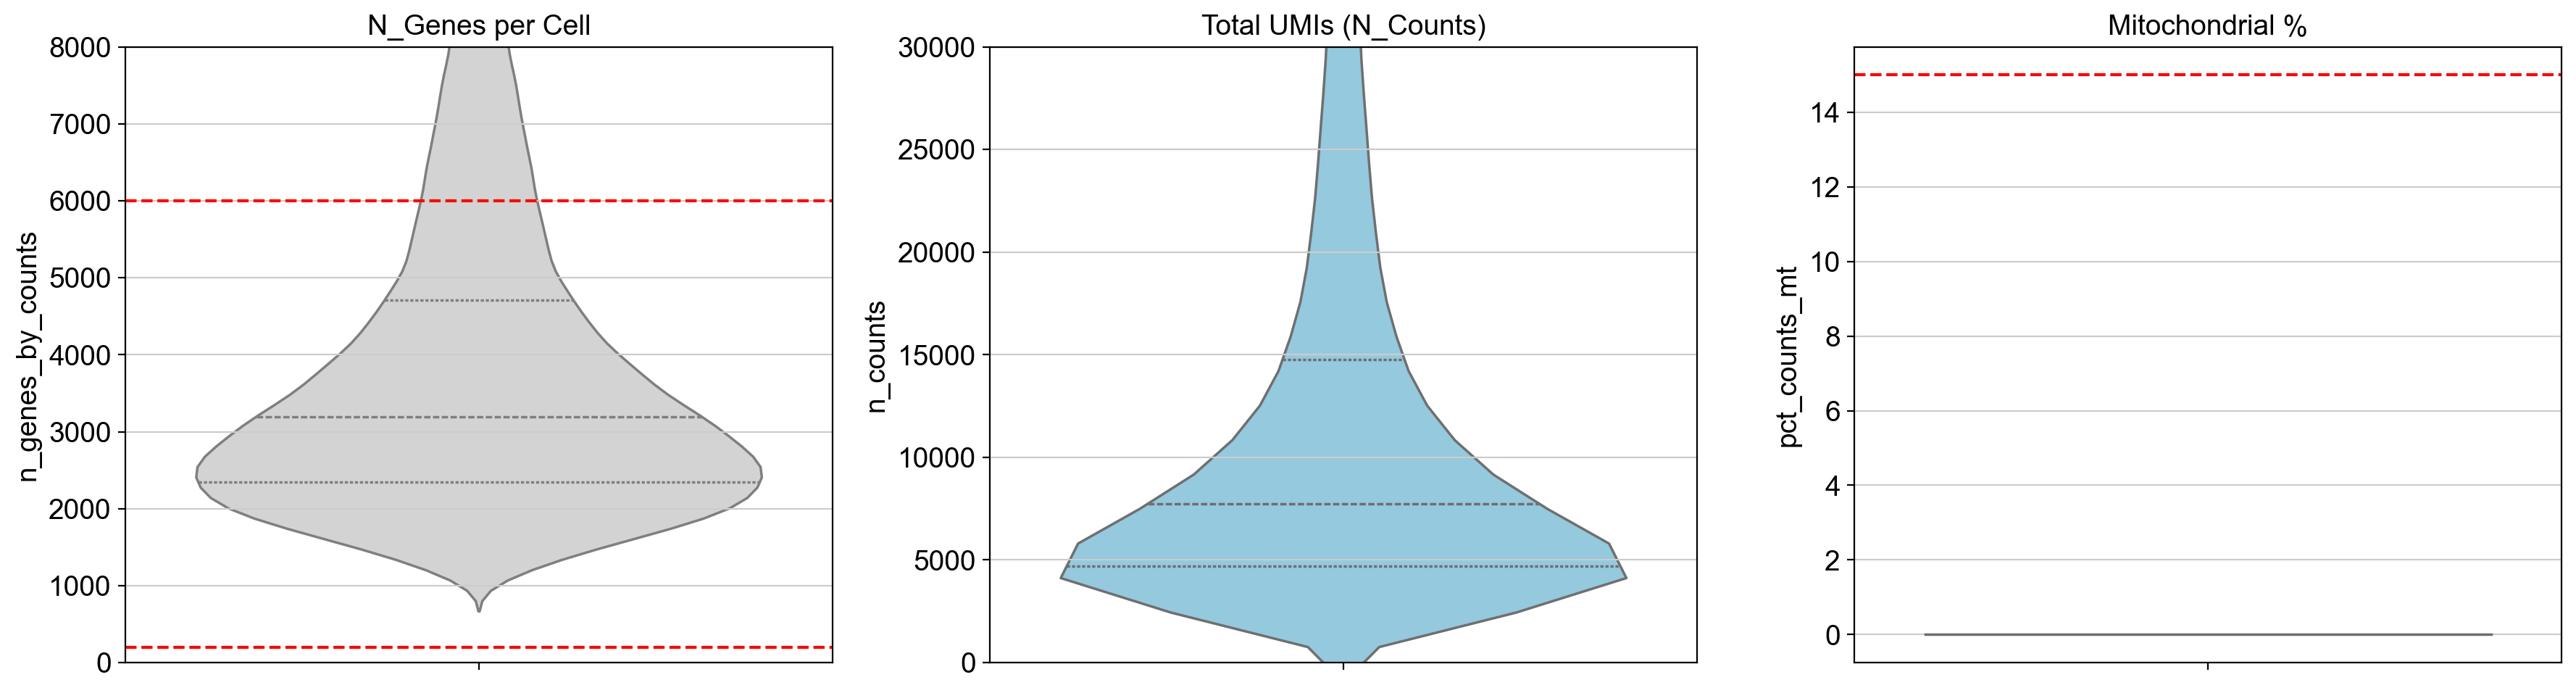


⚠️ Observez la figure pour ajuster les seuils dans la cellule suivante. (200/6000 gènes, 15% MT sont des suggestions)


In [17]:
# --- 4.1.2 VISUALISATION DES DISTRIBUTIONS QC (VIOLIN PLOTS) ---
# L'objectif est d'identifier les seuils de coupe (seuil bas pour les débris, seuil haut pour les doublets)

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Nombres de gènes par cellule
sns.violinplot(y=adata.obs['n_genes_by_counts'], ax=axes[0], color='lightgray', inner='quartile')
axes[0].set_title('N_Genes per Cell')
axes[0].axhline(y=200, color='r', linestyle='--') # Seuil Min (débris)
axes[0].axhline(y=6000, color='r', linestyle='--') # Seuil Max (doublets)
axes[0].set_ylim(0, 8000) # Zoom sur la zone d'intérêt

# 2. Total des UMIs (Profondeur de séquençage)
sns.violinplot(y=adata.obs['n_counts'], ax=axes[1], color='skyblue', inner='quartile')
axes[1].set_title('Total UMIs (N_Counts)')
axes[1].set_ylim(0, 30000)

# 3. Pourcentage Mitochondrial (Qualité)
sns.violinplot(y=adata.obs['pct_counts_mt'], ax=axes[2], color='salmon', inner='quartile')
axes[2].set_title('Mitochondrial %')
axes[2].axhline(y=15, color='r', linestyle='--') # Seuil Max (cellules stressées)

plt.tight_layout()

# Sauvegarde pour le rapport
plt.savefig(os.path.join(DIRS["FIGURES"], "qc_violin_plots.png"), dpi=300)
plt.show()

print("\n⚠️ Observez la figure pour ajuster les seuils dans la cellule suivante. (200/6000 gènes, 15% MT sont des suggestions)")

**3-Threshold Application & Creation of 'adata_qc':**
Apply the determined thresholds (MT%, n_genes) and create the clean adata_qc object, ready for clinical filtering.

In [18]:
# --- 4.1.3 APPLICATION DES FILTRES ET CRÉATION DE adata_qc ---

# Définition des seuils finaux (BASÉS SUR LE CONTEXTE snRNA-seq CORTEX)
MIN_GENES = 1000   # Min 1000 gènes pour exclure les débris de snRNA-seq
MAX_GENES = 6000   # Max 6000 gènes pour éliminer les doublets
MAX_PCT_MT = 5     # Max 5% MT pour garantir une haute qualité (snRNA)

print(f"📉 Cellules avant filtrage QC : {adata.n_obs:,}")

# 1. Filtrage des cellules (lignes)
# Le masque utilise le <= pour être précis sur la limite haute
valid_cells = (adata.obs['n_genes_by_counts'] >= MIN_GENES) & \
              (adata.obs['n_genes_by_counts'] <= MAX_GENES) & \
              (adata.obs['pct_counts_mt'] <= MAX_PCT_MT)
              
# Création de l'objet QC nettoyé
adata_qc = adata[valid_cells].copy()

# 2. Filtrage des gènes (colonnes)
# On enlève les gènes qui sont détectés dans moins de 3 cellules restantes
sc.pp.filter_genes(adata_qc, min_cells=3)

print(f"✅ Cellules après filtrage QC : {adata_qc.n_obs:,} (jetées: {adata.n_obs - adata_qc.n_obs:,})")
print(f"✅ Gènes conservés : {adata_qc.n_vars:,}")

# 3. Libération de la mémoire
## del adata

📉 Cellules avant filtrage QC : 285,076
✅ Cellules après filtrage QC : 243,011 (jetées: 42,065)
✅ Gènes conservés : 34,176


### Target Cohort Selection and Comorbidity Exclusion
Isolate the target cohort (AD/PD/Normal) by applying string matching filters and excluding complex co-diagnoses to create the final clean object (adata_filtered).

----------------------------------------------------------------------
📊 Démarrage de la sélection stricte de la cohorte (AD, PD, CTRL) basée sur les critères diagnostiques et l'ascendance génétique...
🔬 Nombre de noyaux en entrée (après QC) : 243,011
   → Noyaux AD retenus :   25,301
   → Noyaux PD retenus :   7,023
   → Noyaux CTRL retenus : 30,476
   → Mélange aléatoire effectué (seed = 42).
----------------------------------------------------------------------
✅ Objet final 'adata_filtered' créé.
📊 Nombre total de noyaux retenus : 62,800

Distribution des diagnostics (colonne 'disease') :
disease
normal                           30476
dementia || Alzheimer disease    25301
dementia || Parkinson disease     7023
Name: count, dtype: int64
----------------------------------------------------------------------

📊 Résumé des diagnostics (colonne brute 'disease') :
disease
normal                           30476
dementia || Alzheimer disease    25301
dementia || Parkinson disease     7023

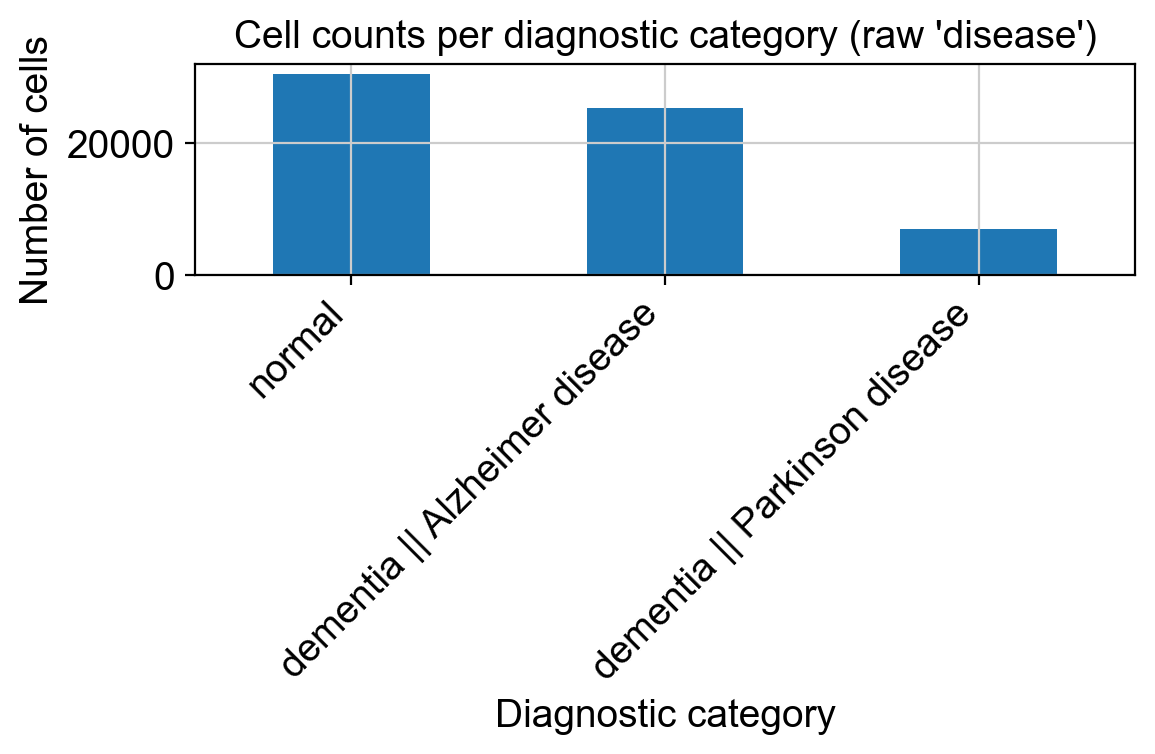

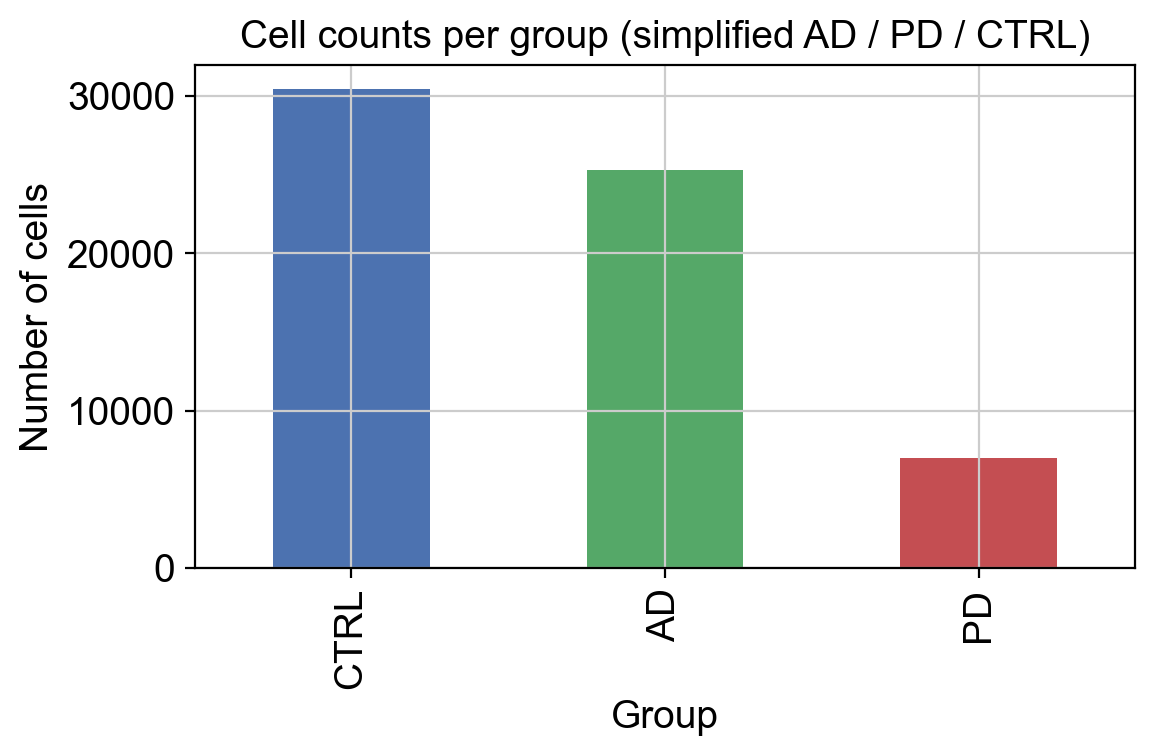

In [19]:
# --- ÉTAPE DE SÉLECTION DE COHORTE (FILTRAGE STRICT et CRÉATION DE L'OBJET FINAL) ---

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

print("-" * 70)
print("📊 Démarrage de la sélection stricte de la cohorte (AD, PD, CTRL) basée sur les critères diagnostiques et l'ascendance génétique...")
print(f"🔬 Nombre de noyaux en entrée (après QC) : {adata_qc.n_obs:,}")

# 1. Définition des masques booléens EXACTS
# Ces filtres suivent strictement la méthodologie définie dans le projet :
# - sélection via la variable 'disease'
# - exclusion des ascendances African et unknown (pour cohérence interne du dataset)

is_AD = (
    (adata_qc.obs['disease'] == "dementia || Alzheimer disease") &
    (adata_qc.obs['genetic_ancestry'] != "African") &
    (adata_qc.obs['genetic_ancestry'] != "unknown")
)

is_PD = (
    (adata_qc.obs['disease'] == "dementia || Parkinson disease") &
    (adata_qc.obs['genetic_ancestry'] != "African")
)

is_CTRL = (
    (adata_qc.obs['disease'] == "normal") &
    (adata_qc.obs['genetic_ancestry'] != "African") &
    (adata_qc.obs['genetic_ancestry'] != "unknown")
)

# 2. Extraction des indices de cellules correspondant à chaque groupe
AD_idx = np.flatnonzero(is_AD)
PD_idx = np.flatnonzero(is_PD)
CTRL_idx = np.flatnonzero(is_CTRL)

print(f"   → Noyaux AD retenus :   {len(AD_idx):,}")
print(f"   → Noyaux PD retenus :   {len(PD_idx):,}")
print(f"   → Noyaux CTRL retenus : {len(CTRL_idx):,}")

# 3. Mélange aléatoire (shuffle)
# Seed fixé pour garantir la reproductibilité du pipeline.
np.random.seed(42)
np.random.shuffle(AD_idx)
np.random.shuffle(PD_idx)
np.random.shuffle(CTRL_idx)

print("   → Mélange aléatoire effectué (seed = 42).")

# 4. Concaténation
final_idx = np.concatenate([AD_idx, PD_idx, CTRL_idx])

# 5. Création de l'objet filtré
adata_filtered = adata_qc[final_idx, :].copy()

print("-" * 70)
print("✅ Objet final 'adata_filtered' créé.")
print(f"📊 Nombre total de noyaux retenus : {adata_filtered.n_obs:,}")

# 6. Résumé diagnostic
print("\nDistribution des diagnostics (colonne 'disease') :")
print(adata_filtered.obs['disease'].value_counts())

print("-" * 70)



# ======================================================================
# AJOUT : Annotation simplifiée pour AD / PD / CTRL
# ======================================================================

adata_filtered.obs['simple_diagnosis'] = adata_filtered.obs['disease'].map({
    "normal": "CTRL",
    "dementia || Alzheimer disease": "AD",
    "dementia || Parkinson disease": "PD"
})

adata_filtered.obs['simple_diagnosis'] = adata_filtered.obs['simple_diagnosis'].astype('category')

# ======================================================================
# VISUALISATIONS POUR LE RAPPORT
# ======================================================================

print("\n📊 Résumé des diagnostics (colonne brute 'disease') :")
print(adata_filtered.obs['disease'].value_counts())

print("\n📊 Résumé des diagnostics simplifiés ('simple_diagnosis') :")
print(adata_filtered.obs['simple_diagnosis'].value_counts())

# --- Barplot 1 : diagnostic brut ('disease') --------------------------
plt.figure(figsize=(6,4))
adata_filtered.obs['disease'].value_counts().plot(kind='bar')
plt.title("Cell counts per diagnostic category (raw 'disease')")
plt.ylabel("Number of cells")
plt.xlabel("Diagnostic category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.ylim(0, 32000)
plt.show()

# --- Barplot 2 : diagnostic simplifié ('simple_diagnosis') ------------
plt.figure(figsize=(6,4))
adata_filtered.obs['simple_diagnosis'].value_counts().plot(
    kind='bar', color=['#4C72B0','#55A868','#C44E52']
)
plt.title("Cell counts per group (simplified AD / PD / CTRL)")
plt.ylabel("Number of cells")
plt.xlabel("Group")
plt.tight_layout()
plt.ylim(0, 32000)
plt.show()

# Commentaire pour le rapport :
# Ces visualisations permettent d’évaluer la répartition des groupes diagnostiques
# et d’identifier la représentation la plus adaptée pour la communication des résultats.



# ----------------------------------------------------------------------
# Option de suppression mémoire (désactivée par défaut)
# ----------------------------------------------------------------------
# try:
#     del adata_filtered
#     print("Objet 'adata_filtered' supprimé de la mémoire.")
# except NameError:
#     print("Objet 'adata_filtered' absent ou déjà supprimé.")
# ----------------------------------------------------------------------


# **Figure 1 : QC Impact Visualization (Violin Plot)**
Génération d'un violin plot comparant les métriques QC **avant** et **après** filtrage.

**Métriques visualisées :** `n_genes_by_counts`, `total_counts`, `pct_counts_mt`

**Output :** `Fig1_QC_ViolinPlot_BeforeAfter.png`

----------------------------------------------------------------------
📊 Génération Figure 1 : QC Violin Plot
----------------------------------------------------------------------
✅ Sauvegardée : Fig1_QC_ViolinPlot.png


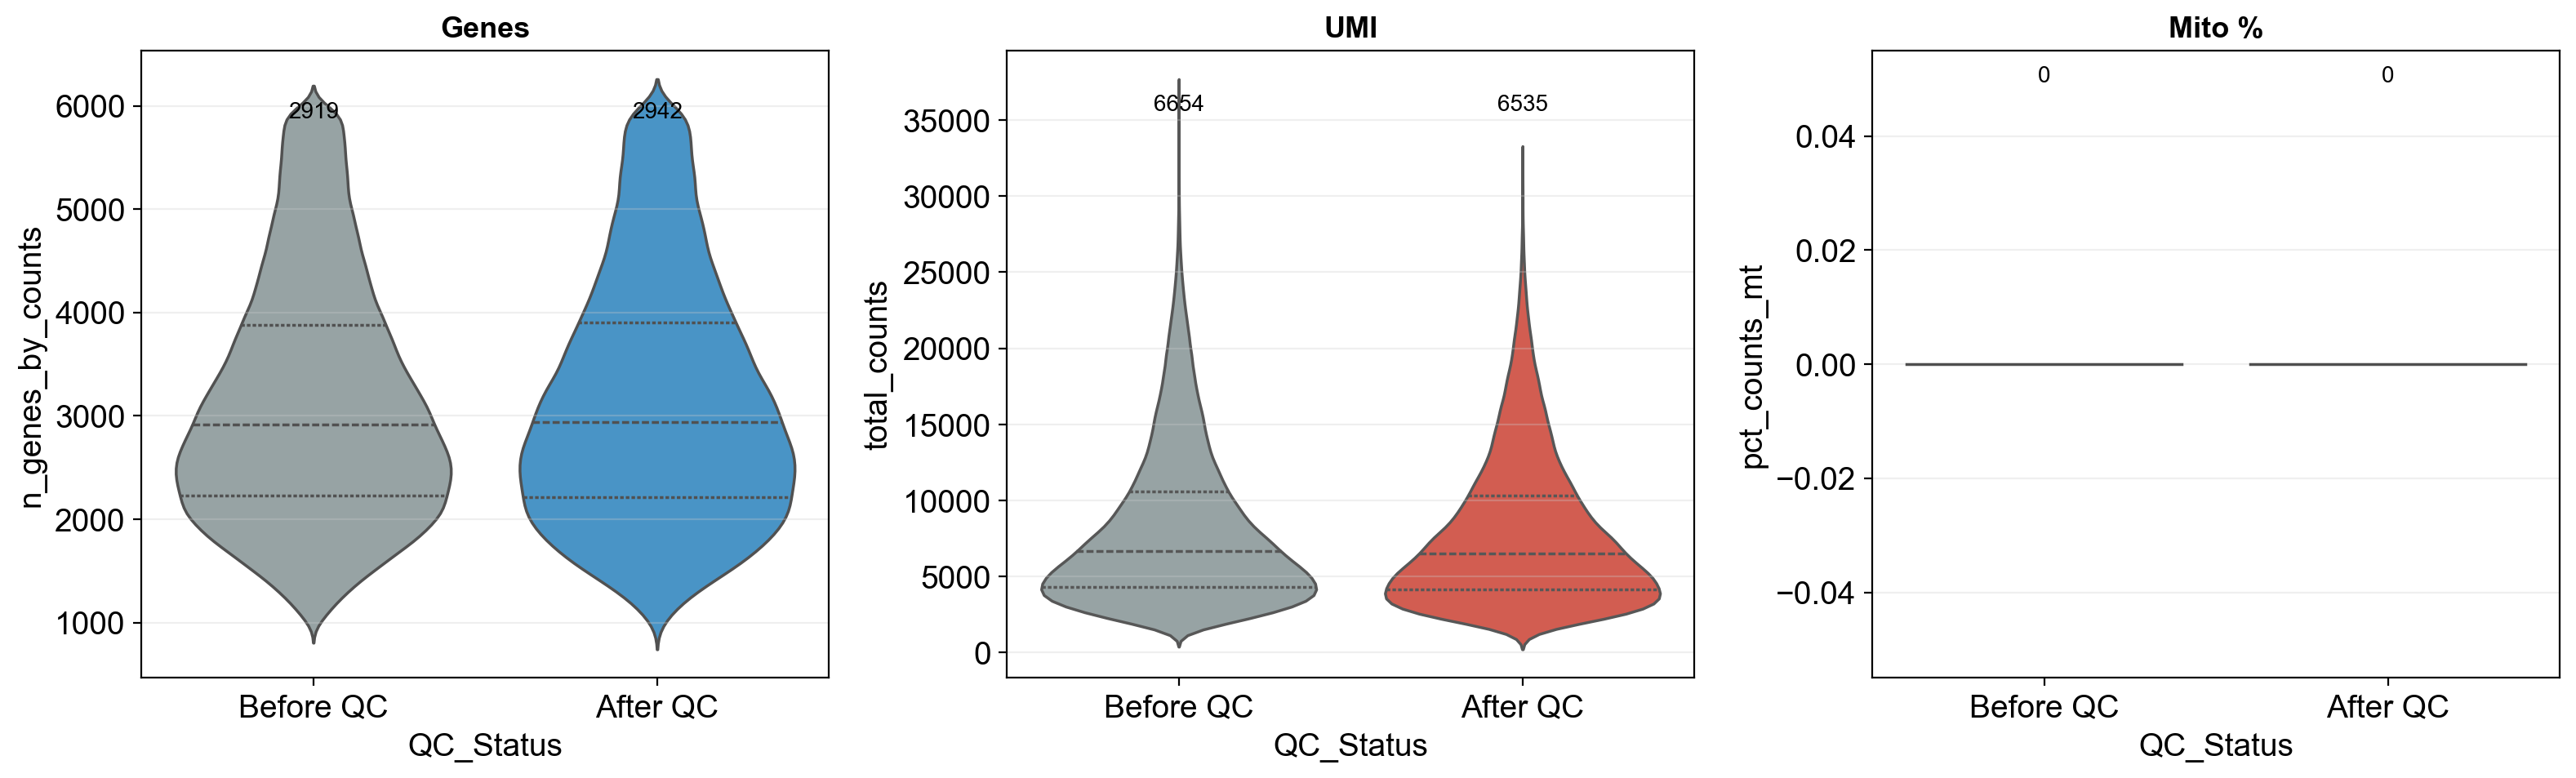

✅ Cellules: 62,800/243,011 (25.8%)
----------------------------------------------------------------------


In [21]:
# --- FIGURE 1 : VIOLIN PLOT QC (AVANT/APRÈS) ---
import matplotlib.pyplot as plt
import seaborn as sns

print("-" * 70)
print("📊 Génération Figure 1 : QC Violin Plot")
print("-" * 70)

try:
    data_before = adata_qc.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].copy()
    data_after = adata_filtered.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].copy()
    data_before['QC_Status'] = 'Before QC'
    data_after['QC_Status'] = 'After QC'
    df_qc = pd.concat([data_before, data_after])
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    metrics = [('n_genes_by_counts', 'Genes', '#3498db'),
               ('total_counts', 'UMI', '#e74c3c'),
               ('pct_counts_mt', 'Mito %', '#f39c12')]
    
    for ax, (metric, label, color) in zip(axes, metrics):
        sns.violinplot(data=df_qc, x='QC_Status', y=metric, ax=ax,
                      palette=['#95a5a6', color], inner='quartile')
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        med_b = data_before[metric].median()
        med_a = data_after[metric].median()
        ax.text(0, ax.get_ylim()[1]*0.9, f'{med_b:.0f}', ha='center', fontsize=10)
        ax.text(1, ax.get_ylim()[1]*0.9, f'{med_a:.0f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS['FIGURES'], 'Fig1_QC_ViolinPlot.png'), dpi=300, bbox_inches='tight')
    print(f"✅ Sauvegardée : Fig1_QC_ViolinPlot.png")
    plt.show()
    print(f"✅ Cellules: {adata_filtered.n_obs:,}/{adata_qc.n_obs:,} ({100*adata_filtered.n_obs/adata_qc.n_obs:.1f}%)")
except NameError:
    print("⚠️  'adata_qc' introuvable. Ajouter 'adata_qc = adata.copy()' avant le QC.")
print("-" * 70)


### Creating the Reduced AnnData Object and Final Summary
Create an in-memory copy of the filtered data subset ready for complex processing (normalization, dimensionality reduction). Generate a final statistical summary to validate the reduced dataset's quality, including final dimensions, donor count per group, and balance of crucial covariates (age, sex, ancestry).

In [23]:
# --- ÉTAPE 4.2.3 : RÉSUMÉ STATISTIQUE ET VALIDATION DES COVARIABLES POUR LE RAPPORT ---

import pandas as pd
import numpy as np

# Note : Les statistiques d'Âge et de PMI ont été omises car les colonnes numériques sont
# absentes du dataset fourni. Cette limitation sera documentée dans le rapport.

# La colonne de regroupement est 'simple_diagnosis' (utilitaire pour la clarté du rapport).
diagnosis_col = 'simple_diagnosis' 

print("-" * 70)
print("📈 Synthèse statistique de la cohorte 'adata_filtered' pour le Rapport")
print("-" * 70)

# 1. Résumé des dimensions du dataset
n_cells_total = adata_filtered.n_obs
n_genes_total = adata_filtered.n_vars
n_donors_total = adata_filtered.obs['donor_id'].nunique()

print(f"Dimensions finales de l'objet : {n_cells_total:,} noyaux x {n_genes_total:,} gènes.")
print(f"Nombre total de donneurs uniques : {n_donors_total:,}")


# 2. Statistiques de base par groupe de diagnostic (Tableau 1 du Rapport)
# Fournit la composition des groupes d'étude (N noyaux, N donneurs).
summary_df = adata_filtered.obs.groupby(diagnosis_col, observed=True).agg(
    N_Donors=('donor_id', 'nunique'),
    N_Cells=('donor_id', 'count')
).sort_values(by='N_Donors', ascending=False)

print("\n--- Tableau 1 : Distribution des Donneurs et des Noyaux par Diagnostic ---")
print(summary_df.to_markdown(numalign="left", stralign="left", floatfmt=".0f"))
# Fonctionnel : Donne la puissance statistique de chaque groupe pour le rapport.


# 3. Hétérogénéité des Noyaux par Donneurs (Évaluation du Biais d'Échantillonnage)
# Mesure la variabilité du nombre de cellules capturées par donneur (Cell Load).
print("\n--- Tableau 2 : Hétérogénéité des Noyaux (Distribution Cellules/Donneur) ---")
# Création d'une série temporaire comptant les cellules par donneur/diagnostic
donor_cell_counts = adata_filtered.obs.groupby(['donor_id', diagnosis_col], observed=True)['donor_id'].size().to_frame(name='n_cells')
cells_per_donor_summary = donor_cell_counts.groupby(level=1)['n_cells'].describe()
print(cells_per_donor_summary.to_markdown(numalign="left", stralign="left", floatfmt=".0f"))
# Fonctionnel : Justifie l'utilisation de méthodes qui corrigent l'effet "donneur" (e.g., pseudobulk), essentiel en snRNA-seq.


# 4. Équilibre du Sexe (Proportion Male/Female)
# Vérification de l'équilibre de la covariable 'sex'.
print("\n--- Tableau 3 : Équilibre du Sexe (Proportion Male/Female par groupe) ---")
sex_counts = adata_filtered.obs.groupby(diagnosis_col, observed=True)['sex'].value_counts(normalize=True).mul(100).unstack(fill_value=0)
print(sex_counts.to_markdown(numalign="left", stralign="left", floatfmt=".1f"))
# Fonctionnel : Détermine si la variable 'sex' doit être incluse dans le modèle DGE comme covariable d'ajustement.


# 5. Ascendance (Tableau de Contingence)
# Vérification de l'équilibre de la covariable 'genetic_ancestry'.
print("\n--- Tableau 4 : Table de Contingence Ascendance x Diagnostic (Donneurs Uniques) ---")
# Création d'un DataFrame au niveau du donneur
donor_metadata = adata_filtered.obs[['donor_id', diagnosis_col, 'genetic_ancestry']].drop_duplicates()
# Création de la table de contingence
ancestry_crosstab = pd.crosstab(donor_metadata[diagnosis_col], donor_metadata['genetic_ancestry'])
# Normalisation pour obtenir le pourcentage au sein de chaque groupe diagnostique
ancestry_crosstab_perc = ancestry_crosstab.div(ancestry_crosstab.sum(axis=1), axis=0) * 100
print("--- Pourcentages au sein du groupe diagnostique (justification des covariables) ---")
print(ancestry_crosstab_perc.to_markdown(numalign="left", stralign="left", floatfmt=".1f"))
# Fonctionnel : La table de contingence justifie l'inclusion de l'ascendance dans le modèle DGE pour corriger les effets de population.

print("-" * 70)
print("✅ Validation statistique partielle de la cohorte terminée. Les 4 tableaux restants sont prêts pour la rédaction du rapport.")

----------------------------------------------------------------------
📈 Synthèse statistique de la cohorte 'adata_filtered' pour le Rapport
----------------------------------------------------------------------
Dimensions finales de l'objet : 62,800 noyaux x 34,176 gènes.
Nombre total de donneurs uniques : 17

--- Tableau 1 : Distribution des Donneurs et des Noyaux par Diagnostic ---
| simple_diagnosis   | N_Donors   | N_Cells   |
|:-------------------|:-----------|:----------|
| AD                 | 8          | 25301     |
| CTRL               | 6          | 30476     |
| PD                 | 3          | 7023      |

--- Tableau 2 : Hétérogénéité des Noyaux (Distribution Cellules/Donneur) ---
| simple_diagnosis   | count   | mean   | std   | min   | 25%   | 50%   | 75%   | max   |
|:-------------------|:--------|:-------|:------|:------|:------|:------|:------|:------|
| AD                 | 8       | 3163   | 1916  | 576   | 2148  | 2562  | 4634  | 5760  |
| PD                 | 3

# **Subsampling & Reducing Dataset**

### Stratified Downsampling
Reduce the cell count to a manageable size (~62.800 nuclei) while retaining the disease group balance defined in the filtering step.

**Note on Downsampling** : Skipped to avoid losing donors and statistical power, especially in the small PD group.

In [24]:
adata_filtered.n_obs

62800

✅ Graphique PROPRE sauvegardé : C:/Z/AIDA_transcriptomics_project/transcriptomics-code\eda_results\barplot_cohorte_finale_clean.png


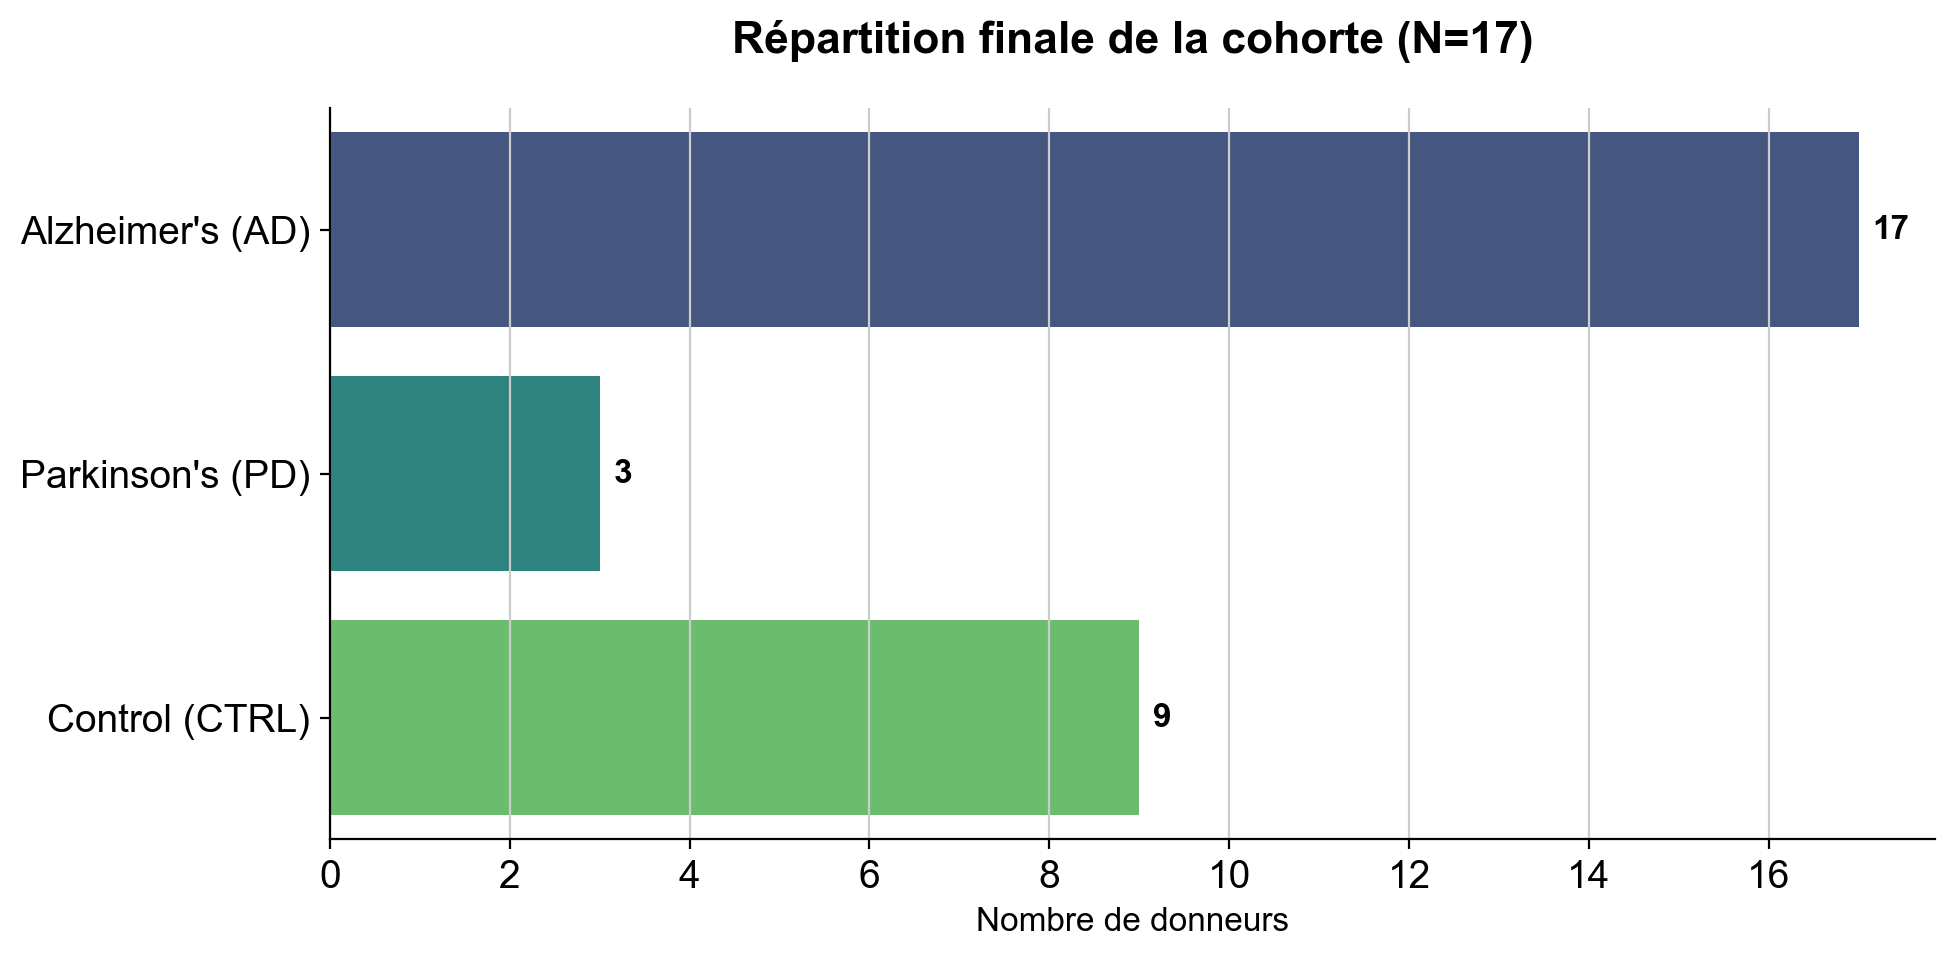

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# --- SCRIPT DE SÉCURITÉ : FILTRAGE + GRAPHIQUE ---

# 1. On définit STRICTEMENT les groupes qu'on veut garder
target_diseases = ["dementia || Alzheimer disease", 
                   "dementia || Parkinson disease", 
                   "normal"]

# 2. On filtre temporairement les données pour le graphique
# (On crée une copie pour ne pas casser votre objet principal 'adata')
subset_adata = adata[adata.obs['disease'].isin(target_diseases)].copy()

# 3. On renomme pour que ce soit joli (Optionnel mais recommandé)
# Cela remplace les noms à rallonge par AD, PD, CTRL
subset_adata.obs['disease'] = subset_adata.obs['disease'].replace({
    "dementia || Alzheimer disease": "Alzheimer's (AD)",
    "dementia || Parkinson disease": "Parkinson's (PD)",
    "normal": "Control (CTRL)"
})

# 4. Calcul des donneurs uniques SUR CE SOUS-ENSEMBLE
donors_stats = subset_adata.obs.groupby("disease", observed=True)["donor_id"].nunique().sort_values(ascending=False)
df_donors = pd.DataFrame({'Unique_Donors': donors_stats})

# --- VISUALISATION ---
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=df_donors['Unique_Donors'],
    y=df_donors.index,
    palette="viridis"
)

plt.title("Répartition finale de la cohorte (N=17)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Nombre de donneurs", fontsize=12)
plt.ylabel("")
sns.despine()

# Chiffres
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=12, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(DIRS["EDA"], "barplot_cohorte_finale_clean.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ Graphique PROPRE sauvegardé : {save_path}")
plt.show()

# **Saving the Reduced Dataset**
The final dataset is saved to the external data directory (outside the Git repository) for use in the subsequent `single_cell_pipeline.ipynb` notebook.

In [26]:
# --- Saving the Filtered Dataset (.h5ad) ---

print("-" * 70)
print("💾 Saving the filtered dataset for downstream analysis...")
print("-" * 70)

# Save directly inside the DATA directory (same location as the original RAW file)
output_dir = DIRS["DATA"]

# File name for the filtered dataset
output_path = os.path.join(output_dir, "adata_filtered.h5ad")

# Save the AnnData object
adata_filtered.write(output_path, compression="gzip")

print(f"✅ File saved successfully:")
print(f"📁 {output_path}")
print("This file will be loaded in the next notebook (single_cell_pipeline.ipynb).")
print("-" * 70)


----------------------------------------------------------------------
💾 Saving the filtered dataset for downstream analysis...
----------------------------------------------------------------------
✅ File saved successfully:
📁 C:/Z/AIDA_transcriptomics_project\data\adata_filtered.h5ad
This file will be loaded in the next notebook (single_cell_pipeline.ipynb).
----------------------------------------------------------------------


# **Figure 2 : Reduction Impact Visualization (Violin Plot)**
Génération d'un violin plot comparant les métriques QC **avant** et **après** reduction.

**Métriques visualisées :** `n_genes_by_counts`, `total_counts`, `pct_counts_mt`

**Output :** `Fig1_Reduction_ViolinPlot_BeforeAfter.png`